# Library imports

In [1]:
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (14, 4)
plt.rcParams['figure.dpi'] = 100

%load_ext autoreload
%autoreload 2

# Preprocessing

Lectura de archivos de audio

Convención de etiquetas:
- PD → label = 1 (clase positiva: enfermedad presente)
- HD → label = 0 (clase negativa: sano)

In [2]:
from src.preprocessing import load_metadata

BASE_PATH = "data"
df_metadata = load_metadata(base_path=BASE_PATH)
files_pd = df_metadata.filter(pl.col("label") == 1)["filepath"].to_list()
files_hd = df_metadata.filter(pl.col("label") == 0)["filepath"].to_list()

## Carga de Señales de Audio (Formas de Onda Crudas)

### Señal digital de audio

Un archivo de audio digital contiene una secuencia de valores de amplitud muestreados a una frecuencia fija (*sample rate*, $sr$):

$$x[n] = x\left(\frac{n}{sr}\right), \quad n = 0, 1, \ldots, N-1$$

donde $N$ es el total de muestras y la duración es $T = N / sr$.

### Decisión de diseño: $sr = 16{,}000$ Hz

Remuestreamos todos los audios a 16 kHz porque:

1. **Teorema de Nyquist-Shannon**: La voz humana relevante está bajo 8 kHz, por lo que $sr \geq 2 \times 8000 = 16000$ es suficiente.
2. **Eficiencia**: Menos muestras que 44.1 kHz sin perder información vocal relevante.


## Preprocesamiento Mínimo

Cuando trabajamos con formas de onda crudas como entrada a modelos de deep learning, el objetivo es **preservar la mayor cantidad de información posible** y dejar que el modelo aprenda sus propias representaciones (Ravanelli & Bengio, 2018).

Por eso, el preprocesamiento se limita a dos operaciones:

### 1. Recorte de silencios (*trimming*)

Elimina segmentos al inicio y final donde la energía está por debajo de un umbral. Se calcula la energía en dB por ventanas:

$$E_{dB}[m] = 20 \times \log_{10}(\text{RMS}[m])$$

donde $\text{RMS}[m] = \sqrt{\frac{1}{K} \sum_{k} x[k]^2}$ es la energía de la ventana $m$.

Se recortan las ventanas donde $E_{dB}[m] < E_{dB}^{max} - \text{top\_db}$. Usamos $\text{top\_db} = 20$, valor estándar en la literatura.

**¿Por qué?** Los silencios iniciales/finales no contienen información sobre la condición del paciente y añaden variabilidad no informativa.

### 2. Normalización de amplitud (*peak normalization*)

Escala la señal para que su valor absoluto máximo sea un valor objetivo:

$$\hat{x}[n] = 0.95 \times \frac{x[n]}{\max(|x[n]|)}$$

**¿Por qué?** Diferentes micrófonos y distancias de grabación producen volúmenes distintos. Sin normalización, el modelo podría aprender a clasificar por volumen en lugar de por patrones vocales.

### Orden del pipeline

1. **Primero** recortar silencios → eliminamos muestras no informativas.
2. **Después** normalizar → la normalización se calcula solo sobre la voz activa.

In [3]:
from src.preprocessing import load_waveforms

TARGET_SR = 16_000
waveforms, df_metadata = load_waveforms(df_metadata, target_sr=TARGET_SR)

# --- resumen ---
print(f"{len(waveforms)} archivos cargados a {TARGET_SR} Hz")
print(f"\nEstadísticas de duración (segundos):")
print(df_metadata.group_by("label_name").agg([
    pl.col("duration_s").mean().alias("media"),
    pl.col("duration_s").min().alias("min"),
    pl.col("duration_s").max().alias("max"),
]))

100 archivos cargados a 16000 Hz

Estadísticas de duración (segundos):
shape: (2, 4)
┌────────────┬──────────┬───────────┬───────────┐
│ label_name ┆ media    ┆ min       ┆ max       │
│ ---        ┆ ---      ┆ ---       ┆ ---       │
│ str        ┆ f64      ┆ f64       ┆ f64       │
╞════════════╪══════════╪═══════════╪═══════════╡
│ PD         ┆ 4.689691 ┆ 1.3895625 ┆ 10.523    │
│ HC         ┆ 4.078074 ┆ 1.6823125 ┆ 8.4749375 │
└────────────┴──────────┴───────────┴───────────┘


In [4]:
from src.preprocessing import preprocess_waveform

# ----------------------------------------------
# REAPLICAR A TODOS LOS AUDIOS
# ----------------------------------------------
waveforms_processed = []
durations_processed = []

for wf in waveforms:
    wf_proc = preprocess_waveform(wf)
    waveforms_processed.append(wf_proc)
    durations_processed.append(len(wf_proc) / TARGET_SR)

df_metadata = df_metadata.with_columns(
    pl.Series("duration_s_processed", durations_processed)
)

print(f"\nComparación de duraciones (segundos):")
print(df_metadata.group_by("label_name").agg([
    pl.col("duration_s").mean().alias("original_media"),
    pl.col("duration_s_processed").mean().alias("procesada_media"),
]))


Comparación de duraciones (segundos):
shape: (2, 3)
┌────────────┬────────────────┬─────────────────┐
│ label_name ┆ original_media ┆ procesada_media │
│ ---        ┆ ---            ┆ ---             │
│ str        ┆ f64            ┆ f64             │
╞════════════╪════════════════╪═════════════════╡
│ PD         ┆ 4.689691       ┆ 4.600234        │
│ HC         ┆ 4.078074       ┆ 4.026524        │
└────────────┴────────────────┴─────────────────┘


## Visualización de recorte de sonido

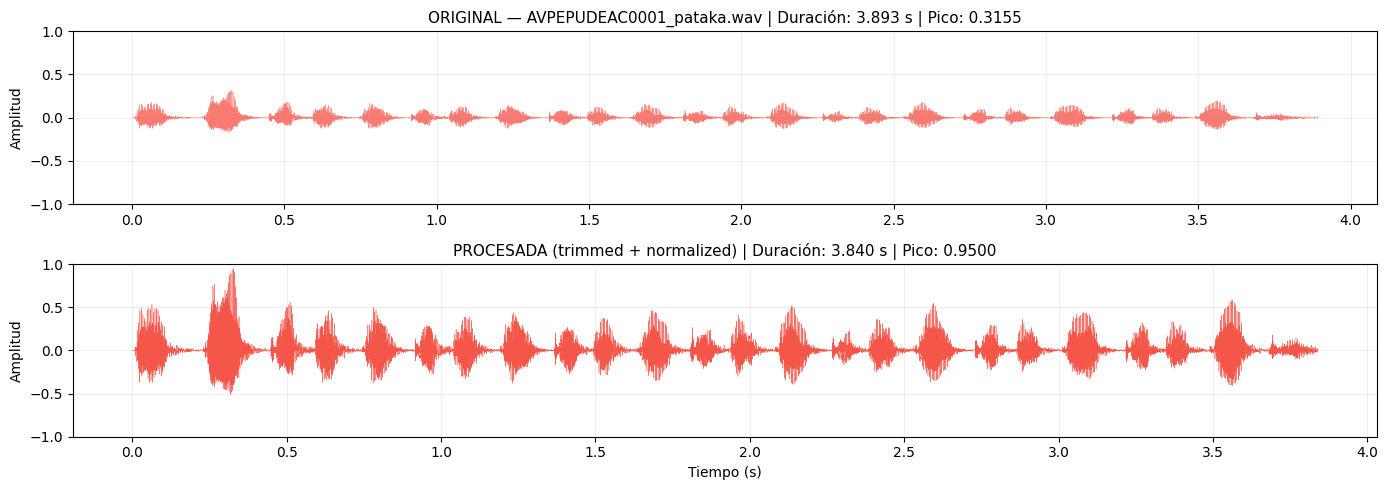

In [11]:
from src.visualization import plot_before_after_preprocessing

idx_hd = df_metadata["label_name"].to_list().index("HC")
idx_pd = df_metadata["label_name"].to_list().index("PD")

fig, axes = plot_before_after_preprocessing(
    idx_hd,
    df_metadata,
    waveforms,
    waveforms_processed
)

fig.savefig(
    "images/hd_before_after.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()
plt.close(fig)

## Unificación de Longitudes (Padding / Truncating)

### ¿Por qué es necesario?

PyTorch trabaja con **tensores de tamaño fijo** dentro de cada batch. Si una señal tiene 20,000 muestras y otra 50,000, no pueden agruparse en un mismo tensor. Necesitamos que todas tengan la misma longitud $L$.

### Estrategia

Dada una longitud objetivo $L$:

- **Si la señal es más corta** ($N < L$): Se rellena con ceros al final (*zero-padding*). Matemáticamente:

$$x_{pad}[n] = \begin{cases} x[n] & \text{si } n < N \\ 0 & \text{si } N \leq n < L \end{cases}$$

- **Si la señal es más larga** ($N > L$): Se recorta desde el inicio (*truncating*), conservando los primeros $L$ valores:

$$x_{trunc}[n] = x[n], \quad n = 0, 1, \ldots, L-1$$

### ¿Cómo elegir $L$?

Opciones comunes:
- **Duración máxima**: No se pierde información, pero genera mucho padding en señales cortas.
- **Percentil 95**: Buen balance — se preserva la mayoría de señales completas y se limita el padding excesivo.
- **Duración media**: Compromiso agresivo — muchas señales se recortan.

Analizaremos la distribución de duraciones para tomar una decisión informada.

{'p50': np.float64(4.0250625), 'p75': np.float64(5.456), 'p90': np.float64(6.6400000000000015), 'p95': np.float64(7.470359374999999), 'max': np.float64(10.464)}


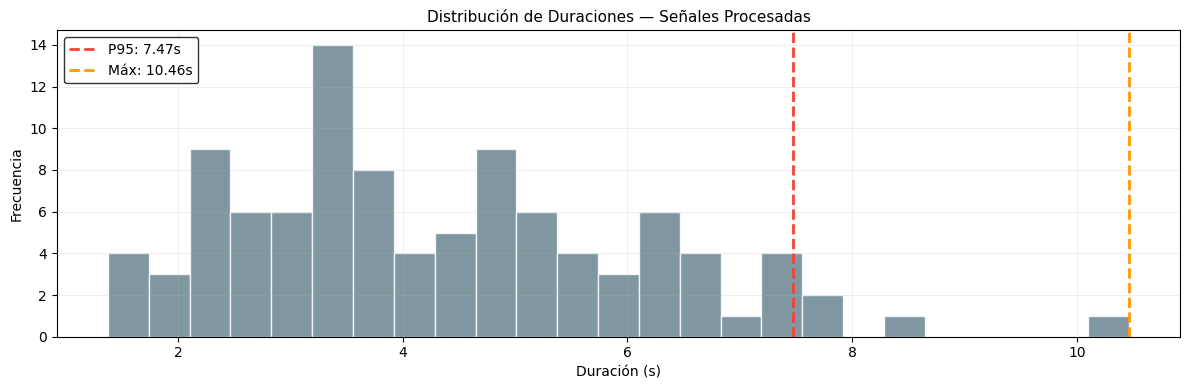

In [15]:
from src.preprocessing import compute_duration_percentiles
from src.visualization import plot_duration_distribution

stats, labels = compute_duration_percentiles(durations_processed)
fig, _ = plot_duration_distribution(durations_processed, stats)


fig.savefig(f'images/distribucion_duracion.png', dpi=200, bbox_inches='tight')
print(stats)

## Aplicación de Padding / Truncating

Se unifica la longitud de todas las señales a **$L = 120{,}000$ muestras (7.5 segundos)**, correspondiente al percentil 95 de las duraciones.

- El 95% de las señales se preservan completas (solo se les agrega ceros al final).
- El 5% restante se recorta, perdiendo información mínima al final de la grabación.
- El *zero-padding* no introduce artefactos en la señal, simplemente extiende con silencio.

In [17]:
from src.preprocessing import pad_or_truncate

TARGET_LENGTH = 120000  # 7.5 segundos a 16 kHz

# ----------------------------------------------
# Aplicar a todas las señales
# ----------------------------------------------
waveforms_fixed = [pad_or_truncate(wf, TARGET_LENGTH) for wf in waveforms_processed]

# ----------------------------------------------
# Verificar
# ----------------------------------------------
n_padded = sum(1 for wf in waveforms_processed if len(wf) < TARGET_LENGTH)
n_truncated = sum(1 for wf in waveforms_processed if len(wf) > TARGET_LENGTH)
n_exact = sum(1 for wf in waveforms_processed if len(wf) == TARGET_LENGTH)

print(f"Todas las señales unificadas a {TARGET_LENGTH:,} muestras ({TARGET_LENGTH/TARGET_SR}s)")
print(f"\n  Señales con padding (eran más cortas): {n_padded}")
print(f"  Señales truncadas (eran más largas): {n_truncated}")
print(f"  Señales sin cambio (longitud exacta): {n_exact}")
print(f"\n  Shape final de cada señal: {waveforms_fixed[0].shape}")

Todas las señales unificadas a 120,000 muestras (7.5s)

  Señales con padding (eran más cortas): 95
  Señales truncadas (eran más largas): 5
  Señales sin cambio (longitud exacta): 0

  Shape final de cada señal: (120000,)


## División del Dataset (Train / Validation / Test)

### ¿Por qué dividir antes de entrenar?

Es fundamental separar los datos **antes** de cualquier paso de modelado para evitar *data leakage* (fuga de información). Si el modelo ve datos de test durante el entrenamiento, las métricas de evaluación no reflejarán su capacidad de generalización real.

### Estrategia

- **Train (70%)**: Para entrenar los modelos.
- **Validation (15%)**: Para ajustar hiperparámetros y monitorear sobreajuste durante el entrenamiento.
- **Test (15%)**: Evaluación final. Solo se usa una vez.

### Estratificación

Usamos **estratificación por clase** para garantizar que la proporción HD/PD se mantenga en cada partición. Con un dataset de 100 archivos (50+50), esto es especialmente importante para evitar desbalances accidentales en particiones pequeñas.

### Reproducibilidad

Se fija una semilla aleatoria (`random_state=42`) para que la división sea exactamente replicable.

In [18]:
RANDOM_STATE = 42

labels = df_metadata["label"].to_numpy()
indices = np.arange(len(waveforms_fixed))

# ----------------------------------------------
# SEPARAR TESTS (15%)
# ----------------------------------------------
idx_train_val, idx_test, y_train_val, y_test = train_test_split(
    indices, labels,
    test_size=0.15,
    stratify=labels,
    random_state=RANDOM_STATE
)

# ----------------------------------------------
# SEPARAR TRAING (70%) Y VALIDATION (15%) DEL RESTANTE (85%)
# ----------------------------------------------
idx_train, idx_val, y_train, y_val = train_test_split(
    idx_train_val, y_train_val,
    test_size=0.176,  # 0.176 de 85% ≈ 15% del total
    stratify=y_train_val,
    random_state=RANDOM_STATE
)

print("División del dataset completada")
print(f"\n{'Partición':<12} {'Total':>6} {'HD (0)':>8} {'PD (1)':>8}")
print("-" * 36)
for name, y in [("Train", y_train), ("Validation", y_val), ("Test", y_test)]:
    n_hd = np.sum(y == 0)
    n_pd = np.sum(y == 1)
    print(f"{name:<12} {len(y):>6} {n_hd:>8} {n_pd:>8}")
print("-" * 36)
print(f"{'Total':<12} {len(labels):>6} {np.sum(labels==0):>8} {np.sum(labels==1):>8}")

División del dataset completada

Partición     Total   HD (0)   PD (1)
------------------------------------
Train            70       35       35
Validation       15        7        8
Test             15        8        7
------------------------------------
Total           100       50       50


## Dataset y DataLoader de PyTorch

### ¿Qué es un Dataset?

En PyTorch, un `Dataset` es una clase que encapsula los datos y permite acceder a cada muestra individualmente mediante un índice. Debe implementar dos métodos:

- `__len__()`: Retorna el número total de muestras.
- `__getitem__(idx)`: Retorna la muestra y su etiqueta en el índice `idx`.

### ¿Qué es un DataLoader?

El `DataLoader` envuelve al `Dataset` y se encarga de:

- **Crear batches**: Agrupa $B$ muestras en un tensor de forma $(B, 1, L)$.
- **Mezclar los datos** (*shuffle*): Aleatoriza el orden en cada época de entrenamiento.
- **Paralelizar la carga**: Usa múltiples workers para cargar datos en segundo plano.

### ¿Por qué forma $(B, 1, L)$?

Las CNNs 1D en PyTorch esperan tensores con la dimensión de canales explícita:

$$\text{input shape} = (B, C, L)$$

donde $B$ = batch size, $C$ = canales (1 para audio mono), $L$ = longitud de la señal.

In [20]:
import torch
from torch.utils.data import Dataset, DataLoader
from src.datasets import ParkinsonWaveformDataset

# ----------------------------------------------
# CREAR LOS DATASETS
# ----------------------------------------------
train_dataset = ParkinsonWaveformDataset(waveforms_fixed, labels, idx_train)
train_dataset = ParkinsonWaveformDataset(waveforms_fixed, labels, idx_train)
val_dataset   = ParkinsonWaveformDataset(waveforms_fixed, labels, idx_val)
val_dataset   = ParkinsonWaveformDataset(waveforms_fixed, labels, idx_val)
test_dataset  = ParkinsonWaveformDataset(waveforms_fixed, labels, idx_test)

# ----------------------------------------------
# CREACION DE DATALOADERS
# ----------------------------------------------
BATCH_SIZE = 8

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

x_batch, y_batch = next(iter(train_loader))
print(f"DataLoaders creados correctamente")
print(f"\n  Train:      {len(train_dataset)} muestras  →  {len(train_loader)} batches")
print(f"  Validation: {len(val_dataset)} muestras  →  {len(val_loader)} batches")
print(f"  Test:       {len(test_dataset)} muestras  →  {len(test_loader)} batches")
print(f"\n  Shape de un batch (x): {x_batch.shape}  →  (batch, canales, longitud)")
print(f"  Shape de un batch (y): {y_batch.shape}  →  (batch,)")
print(f"  Etiquetas del batch:   {y_batch.tolist()}")

DataLoaders creados correctamente

  Train:      70 muestras  →  9 batches
  Validation: 15 muestras  →  2 batches
  Test:       15 muestras  →  2 batches

  Shape de un batch (x): torch.Size([8, 1, 120000])  →  (batch, canales, longitud)
  Shape de un batch (y): torch.Size([8])  →  (batch,)
  Etiquetas del batch:   [0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0]


## Migración: De Zero-Padding a Segmentación por Ventanas (Windowing)

### El problema del zero-padding

Con el enfoque actual, cada señal se ajusta a 120,000 muestras (7.5s) mediante zero-padding.
Para las señales más cortas (mediana ~4s), esto significa que **~47% de la entrada es silencio artificial** (ceros). Los modelos procesan miles de muestras que no contienen información vocal, diluyendo los patrones reales.

### La solución: ventanas deslizantes (sliding windows)

En lugar de extender señales cortas con ceros, **recortamos todas las señales en ventanas de longitud fija** que se deslizan a lo largo de la señal:

$$w_k[n] = x[n + k \cdot H], \quad n = 0, 1, \ldots, W-1$$

donde:
- $W$ = longitud de ventana en muestras (2 segundos = 32,000 muestras a 16 kHz)
- $H$ = hop (desplazamiento entre ventanas consecutivas). Con hop = 1s = 16,000 muestras
- $k$ = índice de ventana

Una señal de 4 segundos genera:

$$N_{\text{ventanas}} = \left\lfloor \frac{L - W}{H} \right\rfloor + 1 = \left\lfloor \frac{64000 - 32000}{16000} \right\rfloor + 1 = 3 \text{ ventanas}$$

### Ventajas

1. **Multiplicación del dataset**: 100 señales → ~500+ ventanas de entrenamiento.
2. **Sin silencio artificial**: Cada ventana contiene señal real al 100%.
3. **Consistencia**: Todos los modelos reciben exactamente la misma cantidad de información.

### Regla crítica: split ANTES de segmentar

La división train/val/test debe hacerse **a nivel de sujeto** (archivo completo), **antes** de generar ventanas. Si segmentamos primero, ventanas del mismo paciente podrían caer en train y test → **data leakage** (el modelo memoriza al paciente, no la patología).
```
CORRECTO:                          INCORRECTO:
Sujeto A → Train                   Señal A → ventana 1 → Train
  ventana A1 → Train                          ventana 2 → Test  ← ¡LEAKAGE!
  ventana A2 → Train                          ventana 3 → Train
  ventana A3 → Train

Sujeto B → Test
  ventana B1 → Test
  ventana B2 → Test
```

### Evaluación a nivel de sujeto

En test, cada sujeto tiene múltiples ventanas. La predicción final del sujeto se obtiene **promediando las probabilidades** de todas sus ventanas:

$$\hat{p}_{\text{sujeto}} = \frac{1}{K} \sum_{k=1}^{K} \sigma(\hat{y}_k)$$

donde $\sigma(\hat{y}_k)$ es la probabilidad sigmoid de la ventana $k$.

In [21]:
from src.preprocessing import segment_waveform

# ----------------------------------------------
# PARÁMETROS DE WINDOWING (ajustados al dataset real)
# ----------------------------------------------
WINDOW_SEC = 0.75                      # 750ms por ventana
HOP_SEC = 0.375                             # 500ms de hop (50% overlap)
WINDOW_LEN = int(WINDOW_SEC * TARGET_SR)   # 12,000 muestras
HOP_LEN = int(HOP_SEC * TARGET_SR)         # 8,000 muestras

print(f"Ventana:  {WINDOW_SEC}s = {WINDOW_LEN:,} muestras")
print(f"Hop:      {HOP_SEC}s = {HOP_LEN:,} muestras")
print(f"Overlap:  {(WINDOW_SEC - HOP_SEC)/WINDOW_SEC*100:.0f}%")

# ----------------------------------------------
# VERIFICAR COBERTURA
# ----------------------------------------------
total_ventanas = 0
sin_ventanas = 0

for i, wf in enumerate(waveforms_processed):
    wins = segment_waveform(waveform=wf, window_len=WINDOW_LEN, hop_len=HOP_LEN)
    total_ventanas += len(wins)
    if len(wins) == 0:
        dur = len(wf) / TARGET_SR
        print(f"  ⚠️  Sujeto {i} sin ventanas: {dur:.3f}s < {WINDOW_SEC}s")
        sin_ventanas += 1

print(f"\n✅ Segmentación con ventana={WINDOW_SEC}s, hop={HOP_SEC}s")
print(f"  Sujetos cubiertos: {100 - sin_ventanas}/100")
print(f"  Sujetos descartados: {sin_ventanas}")
print(f"  Total de ventanas: {total_ventanas}")
print(f"  Promedio ventanas/sujeto: {total_ventanas/(100-sin_ventanas):.1f}")

Ventana:  0.75s = 12,000 muestras
Hop:      0.375s = 6,000 muestras
Overlap:  50%

✅ Segmentación con ventana=0.75s, hop=0.375s
  Sujetos cubiertos: 100/100
  Sujetos descartados: 0
  Total de ventanas: 1002
  Promedio ventanas/sujeto: 10.0


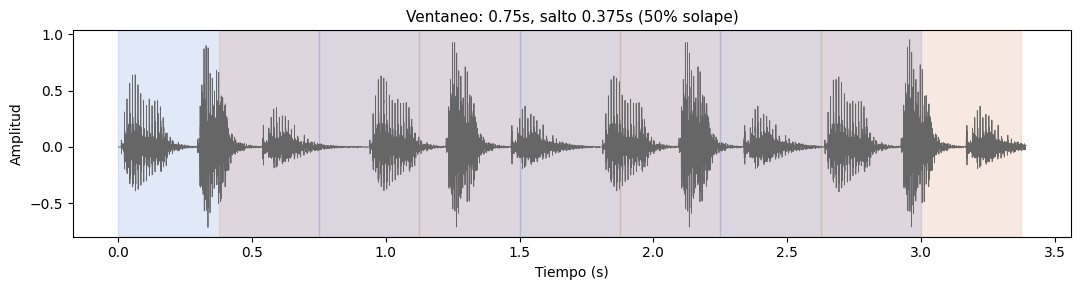

In [23]:
import numpy as np
import matplotlib.pyplot as plt

i = df_metadata["label_name"].to_list().index("PD")
sig = waveforms_processed[i]
sr = 16_000
t = np.arange(len(sig)) / sr

# Crear figura
fig, ax = plt.subplots(
    figsize=(11, 3),
    facecolor="white"
)

# Configuración del eje
ax.set_facecolor("white")
ax.tick_params(axis="both", colors="black")
ax.xaxis.label.set_color("black")
ax.yaxis.label.set_color("black")
ax.title.set_color("black")

for spine in ax.spines.values():
    spine.set_color("black")

# Señal
ax.plot(t, sig, lw=0.6, color="0.4")

# Ventanas
for k, start in enumerate(range(0, len(sig) - WINDOW_LEN + 1, HOP_LEN)):
    ax.axvspan(
        start / sr,
        (start + WINDOW_LEN) / sr,
        color=("C0" if k % 2 == 0 else "C1"),
        alpha=0.15,
    )

ax.set_xlabel("Tiempo (s)", color="black")
ax.set_ylabel("Amplitud", color="black")
ax.set_title(
    f"Ventaneo: {WINDOW_LEN / sr:.2f}s, salto {HOP_LEN / sr:.3f}s (50% solape)",
    fontsize=11,
    color="black",
)

plt.tight_layout()

# Guardar en PDF y PNG
fig.savefig(
    "images/ventaneo.pdf",
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
)
fig.savefig(
    "images/ventaneo.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
)

# Opcional: mostrar
# plt.show()

In [11]:
from sklearn.model_selection import train_test_split
from src.datasets import build_windowed_dataset

RANDOM_STATE = 42

# ── 1. División a nivel de SUJETO (antes de segmentar) ──────
labels = df_metadata["label"].to_numpy()
indices = np.arange(len(waveforms_processed))

# Separar Test (15%)
idx_train_val, idx_test, y_tv, y_test = train_test_split(
    indices, labels,
    test_size=0.15,
    stratify=labels,
    random_state=RANDOM_STATE,
)

# Separar Train (70%) y Validation (15%) del 85% restante
idx_train, idx_val, y_train, y_val = train_test_split(
    idx_train_val, y_tv,
    test_size=0.176,   # 0.176 × 85% ≈ 15% del total
    stratify=y_tv,
    random_state=RANDOM_STATE,
)

print("División a nivel de SUJETO (antes de segmentar):")
print(f"  Train:      {len(idx_train)} sujetos")
print(f"  Validation: {len(idx_val)} sujetos")
print(f"  Test:       {len(idx_test)} sujetos")

X_train, y_train_w, subj_train = build_windowed_dataset(
    idx_train,
    y_train,
    waveforms_processed,
    WINDOW_LEN,
    HOP_LEN
)
X_val, y_val_w, subj_val = build_windowed_dataset(
    idx_val,
    y_val,
    waveforms_processed,
    WINDOW_LEN,
    HOP_LEN
)
X_test, y_test_w, subj_test = build_windowed_dataset(
    idx_test,
    y_test,
    waveforms_processed,
    WINDOW_LEN,
    HOP_LEN
)

print(f"\nVentanas generadas:")
print(f"  {'Partición':<12} {'Sujetos':>8} {'Ventanas':>10} {'HD':>6} {'PD':>6}")
print(f"  {'-'*44}")
for name, X, y in [("Train", X_train, y_train_w),
                     ("Validation", X_val, y_val_w),
                     ("Test", X_test, y_test_w)]:
    n_hd = int(np.sum(y == 0))
    n_pd = int(np.sum(y == 1))
    print(f"  {name:<12} {'-':>8} {len(X):>10} {n_hd:>6} {n_pd:>6}")

print(f"\n  Shape de cada ventana: {X_train[0].shape}")
print(f"  Multiplicación del dataset: {len(labels)} sujetos → {len(X_train)+len(X_val)+len(X_test)} ventanas")

División a nivel de SUJETO (antes de segmentar):
  Train:      70 sujetos
  Validation: 15 sujetos
  Test:       15 sujetos

Ventanas generadas:
  Partición     Sujetos   Ventanas     HD     PD
  --------------------------------------------
  Train               -        729    323    406
  Validation          -        102     52     50
  Test                -        171     90     81

  Shape de cada ventana: (12000,)
  Multiplicación del dataset: 100 sujetos → 1002 ventanas


### Windowed dataset

In [12]:
from src.datasets import WindowedDataset


# Crear datasets
train_dataset = WindowedDataset(X_train, y_train_w, subj_train)
val_dataset = WindowedDataset(X_val, y_val_w, subj_val)
test_dataset = WindowedDataset(X_test, y_test_w, subj_test)

print(f"Datasets creados:")
print(f"  Train:      {len(train_dataset)} ventanas  →  shape: {train_dataset[0][0].shape}")
print(f"  Validation: {len(val_dataset)} ventanas")
print(f"  Test:       {len(test_dataset)} ventanas")

Datasets creados:
  Train:      729 ventanas  →  shape: torch.Size([1, 12000])
  Validation: 102 ventanas
  Test:       171 ventanas


# Arquitecturas

## Arquitectura 1: Red Neuronal Convolucional 1D (CNN 1D)

### ¿Por qué CNN 1D para audio crudo?

Una CNN 1D aplica filtros que se deslizan a lo largo del eje temporal de la señal. Cada filtro aprende a detectar un patrón local específico (un "motivo" temporal). Esto es análogo a cómo una CNN 2D detecta bordes o texturas en imágenes, pero en una sola dimensión.

### ¿Qué puede aprender de señales de Parkinson?

- **Capas iniciales**: Patrones de baja abstracción como oscilaciones de frecuencia fundamental, variaciones rápidas de amplitud (shimmer/jitter).
- **Capas profundas**: Combinaciones de patrones que representan irregularidades articulatorias, temblor vocal, o cambios de ritmo característicos de la enfermedad.

### Operación de convolución 1D

Dado un filtro $w$ de tamaño $k$ y una señal de entrada $x$, la salida en la posición $t$ es:

$$(x * w)[t] = \sum_{i=0}^{k-1} x[t + i] \cdot w[i]$$

Cada capa convolucional aplica múltiples filtros, generando múltiples "mapas de características" que capturan diferentes patrones temporales.

### Arquitectura propuesta

| Capa | Operación | Salida |
|------|-----------|--------|
| Conv1d + ReLU + BatchNorm | 1 → 32 filtros, kernel=7 | Patrones locales finos |
| MaxPool1d(4) | Reducción temporal ×4 | Compresión |
| Conv1d + ReLU + BatchNorm | 32 → 64 filtros, kernel=5 | Patrones de nivel medio |
| MaxPool1d(4) | Reducción temporal ×4 | Compresión |
| Conv1d + ReLU + BatchNorm | 64 → 128 filtros, kernel=3 | Patrones abstractos |
| AdaptiveAvgPool1d(1) | Promedio global | Vector fijo |
| Linear + Dropout | 128 → 1 | Clasificación binaria |

In [13]:
from src.models import CNN1D

model_cnn = CNN1D()
x_test = torch.randn(2, 1, TARGET_LENGTH)
y_test = model_cnn(x_test)

print("CNN 1D creada correctamente")
print(f"\n  Entrada:  {x_test.shape}  →  (batch, canales, longitud)")
print(f"  Salida:   {y_test.shape}  →  (batch,)")
print(f"\n  Parámetros totales: {sum(p.numel() for p in model_cnn.parameters()):,}")

CNN 1D creada correctamente

  Entrada:  torch.Size([2, 1, 120000])  →  (batch, canales, longitud)
  Salida:   torch.Size([2])  →  (batch,)

  Parámetros totales: 35,841


## CNN 1D — Versión Simplificada

El modelo anterior no generalizó porque con solo 70 muestras de entrenamiento, una red con demasiados parámetros memoriza el training sin aprender patrones transferibles al validation.

### Cambios respecto a la versión anterior

| Aspecto | Anterior | Simplificada |
|---------|----------|-------------|
| Filtros | 32 → 64 → 128 | 16 → 32 → 64 |
| Pooling | MaxPool(4) | MaxPool(8) — más agresivo |
| Dropout | 0.3 | 0.5 — más regularización |
| Learning rate | 1e-3 | 5e-4 — más conservador |

El pooling más agresivo reduce rápidamente la dimensión temporal, forzando al modelo a capturar patrones globales en lugar de memorizar detalles locales.

In [14]:
from src.models import Cnn1dLight

model_cnn_light = Cnn1dLight()
params_original = sum(p.numel() for p in CNN1D().parameters())
params_light = sum(p.numel() for p in model_cnn_light.parameters())

print(f"CNN 1D Light creada")
print(f"\n  Parámetros modelo original:     {params_original:,}")
print(f"  Parámetros modelo simplificado: {params_light:,}")
print(f"  Reducción: {100*(1 - params_light/params_original):.1f}%")

CNN 1D Light creada

  Parámetros modelo original:     35,841
  Parámetros modelo simplificado: 9,217
  Reducción: 74.3%


## Arquitectura 3: SincNet (Ravanelli & Bengio, 2018)

### ¿Qué es SincNet?

SincNet reemplaza la primera capa convolucional de una CNN convencional por **filtros sinc parametrizados**. En lugar de aprender todos los valores del filtro libremente, SincNet aprende únicamente dos parámetros por filtro: la frecuencia de corte baja ($f_1$) y la frecuencia de corte alta ($f_2$).

### Fundamento matemático

Un filtro pasa-banda ideal en el dominio temporal se define como la diferencia de dos funciones sinc:

$$h[n] = 2f_2 \cdot \text{sinc}(2f_2 n) - 2f_1 \cdot \text{sinc}(2f_1 n)$$

donde $\text{sinc}(x) = \frac{\sin(\pi x)}{\pi x}$ y $f_1 < f_2$ son las frecuencias de corte normalizadas.

Este filtro deja pasar únicamente las frecuencias entre $f_1$ y $f_2$, atenuando el resto.

### ¿Por qué funciona para Parkinson?

- Los filtros sinc imponen una **restricción física** (son filtros pasa-banda reales), lo que reduce drásticamente los parámetros aprendibles y actúa como regularización.
- Con solo 80 filtros × 2 parámetros = **160 parámetros** en la primera capa (vs miles en una Conv1d convencional), es ideal para datasets pequeños.
- Los filtros aprenden automáticamente qué bandas de frecuencia son relevantes para distinguir voces patológicas de sanas.

### Arquitectura propuesta

| Capa | Operación | Detalle |
|------|-----------|---------|
| SincConv1d | 80 filtros sinc, kernel=251 | Aprende bandas de frecuencia relevantes |
| Conv1d + BN + ReLU | 60 filtros, kernel=5 | Patrones de nivel medio |
| Conv1d + BN + ReLU | 60 filtros, kernel=5 | Patrones abstractos |
| AdaptiveAvgPool1d(1) | Promedio global | Vector fijo de 60 dimensiones |
| Linear + Dropout | 60 → 1 | Clasificación binaria |

In [15]:
from src.models import SincNet

model_sinc = SincNet()
x_test = torch.randn(2, 1, TARGET_LENGTH)
y_test = model_sinc(x_test)

print(f"SincNet creada correctamente")
print(f"\n  Entrada: {x_test.shape}")
print(f"  Salida:  {y_test.shape}")
print(f"  Parámetros totales: {sum(p.numel() for p in model_sinc.parameters()):,}")
print(f"  Parámetros capa Sinc: {80 * 2} (solo frecuencias de corte)")

SincNet creada correctamente

  Entrada: torch.Size([2, 1, 120000])
  Salida:  torch.Size([2])
  Parámetros totales: 42,741
  Parámetros capa Sinc: 160 (solo frecuencias de corte)


## Arquitectura 4: Wav2vec 2.0 BASE (Fine-tuning)

### ¿Qué es Wav2vec 2.0?

Wav2vec 2.0 (Baevski et al., 2020) es un modelo preentrenado por Facebook AI que aprendió representaciones del habla a partir de **miles de horas de audio sin etiquetar**. Esto significa que el modelo ya "entiende" la estructura del habla humana antes de ver nuestros datos.

### ¿Por qué transfer learning?

Nuestro dataset tiene solo 100 muestras. Entrenar un modelo desde cero con tan pocos datos lleva al sobreajuste (como vimos con las CNNs). En cambio, un modelo preentrenado ya capturó patrones universales del habla y solo necesitamos ajustarlo para nuestra tarea específica.

**Analogía**: Es como contratar a un lingüista experto y pedirle que aprenda a distinguir voces con Parkinson, en lugar de enseñarle desde cero qué es un idioma.

### Estrategia de fine-tuning

Para que funcione en 24GB de RAM:

1. **Congelar** el codificador CNN y la mayoría de capas del Transformer → no se actualizan durante el entrenamiento.
2. **Descongelar** solo las últimas 2 capas del Transformer → se ajustan a nuestra tarea.
3. **Agregar un clasificador** lineal encima → convierte las representaciones en una predicción binaria (PD vs HD).

Esto reduce drásticamente los parámetros entrenables y el consumo de memoria.

### Arquitectura

| Componente | Operación | Entrenamiento |
|------------|-----------|---------------|
| Codificador CNN (7 capas) | Audio crudo → representaciones latentes | 🔒 Congelado |
| Transformer (12 bloques) | Captura contexto temporal | 🔒 Bloques 1-10 congelados |
| Transformer (últimas 2 capas) | Ajuste fino | 🔓 Entrenables |
| Clasificador (Linear) | 768 → 1 | 🔓 Entrenable |

In [16]:
from src.models import Wav2Vec2Classifier

# Verificar
print("Cargando Wav2vec 2.0 BASE (puede tomar unos segundos)...")
model_w2v = Wav2Vec2Classifier()

total_params = sum(p.numel() for p in model_w2v.parameters())
trainable_params = sum(p.numel() for p in model_w2v.parameters() if p.requires_grad)

print(f"\nWav2vec 2.0 Classifier creado")
print(f"\n  Parámetros totales:      {total_params:,}")
print(f"  Parámetros entrenables:  {trainable_params:,}")
print(f"  Parámetros congelados:   {total_params - trainable_params:,}")
print(f"  % entrenable:            {100 * trainable_params / total_params:.1f}%")

Cargando Wav2vec 2.0 BASE (puede tomar unos segundos)...


Loading weights: 100%|██████████| 211/211 [00:00<00:00, 1872.74it/s, Materializing param=masked_spec_embed]                                            
Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-base
Key                          | Status     |  | 
-----------------------------+------------+--+-
project_hid.weight           | UNEXPECTED |  | 
project_q.bias               | UNEXPECTED |  | 
quantizer.codevectors        | UNEXPECTED |  | 
project_hid.bias             | UNEXPECTED |  | 
quantizer.weight_proj.bias   | UNEXPECTED |  | 
project_q.weight             | UNEXPECTED |  | 
quantizer.weight_proj.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Wav2vec 2.0 Classifier creado

  Parámetros totales:      94,372,481
  Parámetros entrenables:  14,176,513
  Parámetros congelados:   80,195,968
  % entrenable:            15.0%


## Arquitectura 5: WaveNet-like (Convoluciones Dilatadas Causales)

### ¿Qué es WaveNet?

WaveNet (van den Oord et al., 2016) fue propuesto originalmente por DeepMind para generación de audio. Su innovación clave son las **convoluciones dilatadas**, que permiten capturar dependencias temporales a largo plazo sin necesidad de capas recurrentes ni pooling agresivo.

### ¿Qué es una convolución dilatada?

Una convolución estándar con kernel de tamaño $k$ observa $k$ muestras consecutivas. Una convolución **dilatada** con factor $d$ inserta $d-1$ espacios entre los elementos del filtro, observando un rango mucho mayor sin aumentar los parámetros:

$$y[t] = \sum_{i=0}^{k-1} w[i] \cdot x[t - d \cdot i]$$

donde $d$ es el factor de dilatación.

**Ejemplo con kernel $k=3$:**
- Dilatación $d=1$: observa 3 muestras consecutivas (campo receptivo = 3)
- Dilatación $d=2$: observa muestras separadas por 2 (campo receptivo = 5)
- Dilatación $d=4$: observa muestras separadas por 4 (campo receptivo = 9)

Al apilar capas con dilataciones crecientes ($d = 1, 2, 4, 8, ...$), el **campo receptivo crece exponencialmente** mientras los parámetros crecen linealmente.

### ¿Por qué sirve para Parkinson?

Las alteraciones vocales en Parkinson incluyen patrones que ocurren a diferentes escalas temporales:
- **Escala corta** (milisegundos): jitter, shimmer, irregularidades de ciclo glotal
- **Escala media** (decenas de ms): transiciones articulatorias, onset/offset de fonemas
- **Escala larga** (cientos de ms): ritmo del habla, pausas, patrones de energía

Las convoluciones dilatadas capturan estas tres escalas simultáneamente sin perder resolución temporal, a diferencia del pooling que comprime la señal irreversiblemente.

### Arquitectura propuesta

Usamos bloques residuales con convoluciones dilatadas crecientes ($d = 1, 2, 4, 8, 16, 32$), lo que da un campo receptivo teórico de 127 muestras (~8ms a 16kHz) por bloque.

| Componente | Detalle |
|------------|---------|
| Conv1d inicial | 1 → 32 canales, adapta la entrada |
| 6 bloques residuales | Dilataciones $d = 1, 2, 4, 8, 16, 32$ con conexiones residuales |
| Cada bloque | Conv1d dilatada → BatchNorm → ReLU → Dropout → Conv1d 1×1 + residual |
| AdaptiveAvgPool1d(1) | Promedio global temporal |
| Linear | 32 → 1, clasificación binaria |

In [17]:
from src.models import WaveNetLike

model_wn = WaveNetLike()
x_test = torch.randn(2, 1, TARGET_LENGTH)
y_test = model_wn(x_test)

print(f"WaveNet-like creada correctamente")
print(f"\n  Entrada: {x_test.shape}")
print(f"  Salida:  {y_test.shape}")
print(f"  Parámetros totales: {sum(p.numel() for p in model_wn.parameters()):,}")
print(f"  Dilataciones: [1, 2, 4, 8, 16, 32]")

WaveNet-like creada correctamente

  Entrada: torch.Size([2, 1, 120000])
  Salida:  torch.Size([2])
  Parámetros totales: 25,441
  Dilataciones: [1, 2, 4, 8, 16, 32]


## Arquitectura 6: Transformer Temporal Lightweight

### Conclusiones
Genera un overfitting, pero todavía no sabemos porque, porque tiene problemas para generalizar

In [18]:
from src.models import TemporalTransformer

# ==============================================================
# VERIFICACIÓN
# ==============================================================
model_tt = TemporalTransformer()
x_test = torch.randn(2, 1, TARGET_LENGTH)
y_test = model_tt(x_test)

total_params = sum(p.numel() for p in model_tt.parameters())
trainable_params = sum(p.numel() for p in model_tt.parameters() if p.requires_grad)

print("Temporal Transformer creado correctamente")
print(f"\n  Entrada:  {x_test.shape}  →  (batch, canales, longitud)")
print(f"  Salida:   {y_test.shape}  →  (batch,)")
print(f"\n  Parámetros totales:      {total_params:,}")
print(f"  Parámetros entrenables:  {trainable_params:,}")

with torch.no_grad():
    conv_out = model_tt.conv_frontend(x_test)
    print(f"\n  Front-end: {TARGET_LENGTH:,} muestras → {conv_out.shape[2]} tokens")
    print(f"  Factor de reducción: {TARGET_LENGTH / conv_out.shape[2]:.0f}x")
    print(f"  Transformer opera sobre: {conv_out.shape[2]} tokens × {conv_out.shape[1]} dim")

Temporal Transformer creado correctamente

  Entrada:  torch.Size([2, 1, 120000])  →  (batch, canales, longitud)
  Salida:   torch.Size([2])  →  (batch,)

  Parámetros totales:      90,241
  Parámetros entrenables:  90,241

  Front-end: 120,000 muestras → 468 tokens
  Factor de reducción: 256x
  Transformer opera sobre: 468 tokens × 64 dim


## Arquitectura 7: HuBERT BASE (Fine-tuning)

In [19]:
from src.models import HuBERTClassifier

# ==============================================================
# VERIFICACIÓN
# ==============================================================
print("Cargando HuBERT BASE (puede tomar unos segundos)...")
model_hubert = HuBERTClassifier()

total_params = sum(p.numel() for p in model_hubert.parameters())
trainable_params = sum(p.numel() for p in model_hubert.parameters() if p.requires_grad)

print(f"\nHuBERT Classifier creado")
print(f"\n  Parámetros totales:      {total_params:,}")
print(f"  Parámetros entrenables:  {trainable_params:,}")
print(f"  Parámetros congelados:   {total_params - trainable_params:,}")
print(f"  % entrenable:            {100 * trainable_params / total_params:.1f}%")

Cargando HuBERT BASE (puede tomar unos segundos)...


Loading weights: 100%|██████████| 211/211 [00:00<00:00, 1655.98it/s, Materializing param=masked_spec_embed]                                            


HuBERT Classifier creado

  Parámetros totales:      94,372,481
  Parámetros entrenables:  14,176,513
  Parámetros congelados:   80,195,968
  % entrenable:            15.0%


## Arquitectura 8: BiLSTM-CNN (Red Híbrida Recurrente-Convolucional)

In [20]:
from src.models import BiLSTM_CNN

# ── Verificación de la arquitectura ─────────────────────────────
model_test = BiLSTM_CNN()
x_dummy = torch.randn(2, 1, 32000)  # batch=2, ventana de 2s a 16kHz
y_dummy = model_test(x_dummy)

print("BiLSTM-CNN creada correctamente")
print(f"\n  Entrada:  {x_dummy.shape}  →  (batch, canales, muestras)")
print(f"  Salida:   {y_dummy.shape}  →  (batch,)")

# Contar parámetros
total_params = sum(p.numel() for p in model_test.parameters())
trainable_params = sum(p.numel() for p in model_test.parameters() if p.requires_grad)
print(f"\n  Parámetros totales:      {total_params:,}")
print(f"  Parámetros entrenables:  {trainable_params:,}")

# Desglose por etapa
cnn_params = sum(p.numel() for p in model_test.cnn.parameters())
lstm_params = sum(p.numel() for p in model_test.lstm.parameters())
cls_params = sum(p.numel() for p in model_test.classifier.parameters())
print(f"\n  CNN:           {cnn_params:,} ({100*cnn_params/total_params:.1f}%)")
print(f"  BiLSTM:        {lstm_params:,} ({100*lstm_params/total_params:.1f}%)")
print(f"  Clasificador:  {cls_params:,} ({100*cls_params/total_params:.1f}%)")

del model_test, x_dummy, y_dummy

BiLSTM-CNN creada correctamente

  Entrada:  torch.Size([2, 1, 32000])  →  (batch, canales, muestras)
  Salida:   torch.Size([2])  →  (batch,)

  Parámetros totales:      234,497
  Parámetros entrenables:  234,497

  CNN:           35,712 (15.2%)
  BiLSTM:        198,656 (84.7%)
  Clasificador:  129 (0.1%)


## Arquitectura 9: CNN-Attention (Convolución + Self-Attention)

### Motivación

BiLSTM-CNN demostró que combinar extracción local (CNN) con modelado de contexto temporal mejora significativamente el rendimiento. Sin embargo, la BiLSTM procesa la secuencia de forma **secuencial** (paso a paso), lo cual tiene dos limitaciones:

1. **Sesgo de recencia**: Los últimos estados ocultos tienden a ponderar más los timesteps recientes.
2. **Costo computacional**: La recurrencia impide paralelización.

El mecanismo de **Self-Attention** resuelve ambos problemas. En lugar de procesar secuencialmente, calcula directamente la relevancia entre **todos los pares de posiciones** simultáneamente.

### Concepto matemático

#### Self-Attention (Scaled Dot-Product)

Dada una secuencia de vectores $\mathbf{H} = [\mathbf{h}_1, \ldots, \mathbf{h}_T] \in \mathbb{R}^{T \times d}$ (salida de la CNN), se proyectan en tres espacios:

$$\mathbf{Q} = \mathbf{H}\mathbf{W}_Q, \quad \mathbf{K} = \mathbf{H}\mathbf{W}_K, \quad \mathbf{V} = \mathbf{H}\mathbf{W}_V$$

donde $\mathbf{Q}$ (Query), $\mathbf{K}$ (Key), $\mathbf{V}$ (Value) $\in \mathbb{R}^{T \times d_k}$.

La atención se calcula como:

$$\text{Attention}(\mathbf{Q}, \mathbf{K}, \mathbf{V}) = \text{softmax}\left(\frac{\mathbf{Q}\mathbf{K}^\top}{\sqrt{d_k}}\right)\mathbf{V}$$

**Interpretación**: El producto $\mathbf{Q}\mathbf{K}^\top$ genera una **matriz de afinidad** $T \times T$ donde cada entrada $(i, j)$ mide cuánta atención debe prestar la posición $i$ a la posición $j$. La división por $\sqrt{d_k}$ estabiliza los gradientes. El softmax normaliza las afinidades a pesos probabilísticos. Finalmente, se pondera $\mathbf{V}$ con estos pesos.

#### Multi-Head Attention

En lugar de una sola función de atención, se usan $h$ "cabezas" independientes que capturan distintos tipos de relaciones:

$$\text{MultiHead}(\mathbf{H}) = \text{Concat}(\text{head}_1, \ldots, \text{head}_h)\mathbf{W}_O$$

donde $\text{head}_i = \text{Attention}(\mathbf{H}\mathbf{W}_Q^i, \mathbf{H}\mathbf{W}_K^i, \mathbf{H}\mathbf{W}_V^i)$

#### Aggregation (Attention Pooling)

Para obtener un vector fijo a partir de la secuencia atendida, usamos **attention pooling**: un vector de query aprendible $\mathbf{q} \in \mathbb{R}^d$ que calcula pesos de importancia sobre todos los timesteps:

$$\alpha_t = \frac{\exp(\mathbf{q}^\top \mathbf{h}_t)}{\sum_{t'} \exp(\mathbf{q}^\top \mathbf{h}_{t'})}, \qquad \mathbf{z} = \sum_t \alpha_t \mathbf{h}_t$$

Esto permite al modelo **aprender qué regiones de la señal son más informativas** para la clasificación.

### ¿Por qué sirve para Parkinson en ventanas cortas?

- En 0.75s de fonación, las irregularidades vocales (jitter, shimmer) pueden aparecer en **cualquier posición**. La atención permite al modelo enfocarse en los segmentos más anómalos sin importar dónde ocurran.
- A diferencia de BiLSTM, no asume que la información fluye secuencialmente — una perturbación al inicio es tan accesible como una al final.

### Arquitectura
```
Entrada: (batch, 1, 12000)
        │
        ▼
┌──────────────────────────────┐
│  CNN 1D Feature Extractor    │
│  3 bloques Conv+BN+ReLU+Pool │
│  Salida: (batch, 128, T')   │
└──────────────────────────────┘
        │
        ▼  permute → (batch, T', 128)
        │
┌──────────────────────────────┐
│  Multi-Head Self-Attention   │
│  4 cabezas, dim=128          │
│  + LayerNorm + Residual      │
└──────────────────────────────┘
        │
        ▼  (batch, T', 128)
        │
┌──────────────────────────────┐
│  Attention Pooling           │
│  Query aprendible → (batch, 128) │
└──────────────────────────────┘
        │
        ▼
┌──────────────────────────────┐
│  Dropout(0.3) → Linear(1)   │
└──────────────────────────────┘
        │
        ▼  ŷ ∈ ℝ (logit)
```

### Referencias

- Vaswani et al. (2017): "Attention Is All You Need" — introduce el mecanismo de self-attention.
- Bahdanau et al. (2015): Proponen atención aditiva para modelado de secuencias.
- Safari et al. (2020): Aplican self-attention para clasificación de hablante en señales cortas de voz.

In [21]:
from src.models import CNNAttention

# ── Verificación ─────────────────────────────────────────────
model_test = CNNAttention()
x_dummy = torch.randn(2, 1, WINDOW_LEN)
y_dummy = model_test(x_dummy)

total_p = sum(p.numel() for p in model_test.parameters())
print("✅ CNN-Attention creada correctamente")
print(f"  Entrada:  {x_dummy.shape}")
print(f"  Salida:   {y_dummy.shape}")
print(f"  Parámetros totales: {total_p:,}")

del model_test, x_dummy, y_dummy

✅ CNN-Attention creada correctamente
  Entrada:  torch.Size([2, 1, 12000])
  Salida:   torch.Size([2])
  Parámetros totales: 102,273


## Arquitectura 10: ECAPA-TDNN

### Motivación

ECAPA-TDNN (*Emphasized Channel Attention, Propagation and Aggregation — Time Delay Neural Network*) es la arquitectura **estado del arte en verificación de hablante** (Desplanques et al., 2020). Fue diseñada específicamente para extraer representaciones robustas de señales de voz cortas.

### ¿Por qué es relevante para Parkinson?

1. **Diseñada para voz corta**: Funciona con señales de 1-3 segundos, exactamente nuestro rango (0.75s).
2. **Squeeze-and-Excitation (SE)**: Aprende a ponderar **qué canales** (filtros) son más relevantes, permitiendo enfatizar automáticamente los canales que capturan patrones patológicos.
3. **Pooling estadístico**: Captura tanto la **media** como la **desviación estándar** temporal — la variabilidad (shimmer, jitter) es tan informativa como la tendencia central.
4. **Conexiones residuales + densas**: Propagan información de múltiples escalas sin degradación.

### Componentes clave

#### 1. SE-Block (Squeeze-and-Excitation)

Recalibra los canales según su importancia global:

$$\text{SE}(\mathbf{X}) = \mathbf{X} \odot \sigma\left(\mathbf{W}_2 \cdot \text{ReLU}(\mathbf{W}_1 \cdot \text{GAP}(\mathbf{X}))\right)$$

donde GAP es Global Average Pooling sobre el tiempo, $\mathbf{W}_1 \in \mathbb{R}^{C/r \times C}$ comprime, $\mathbf{W}_2 \in \mathbb{R}^{C \times C/r}$ expande, y $r$ es el ratio de reducción. El resultado es un vector de pesos por canal que escala cada mapa de features.

**Interpretación para Parkinson**: Si el canal 47 captura perturbaciones de frecuencia fundamental y el canal 12 captura ruido de fondo, el SE-block aprende a amplificar el 47 y atenuar el 12.

#### 2. Res2Net-style blocks

Cada bloque convolucional divide internamente los canales en $s$ grupos (scales) y los procesa jerárquicamente, generando features **multi-escala** dentro de un solo bloque:

$$\mathbf{y}_i = \begin{cases} \mathbf{x}_i & i = 1 \\ K_i(\mathbf{x}_i + \mathbf{y}_{i-1}) & i > 1 \end{cases}$$

donde $K_i$ es una convolución 1D. Cada scale ve un campo receptivo progresivamente mayor.

#### 3. Attentive Statistical Pooling

En lugar de promediar uniformemente sobre el tiempo, pondera cada timestep por su relevancia:

$$\alpha_t = \frac{\exp(\mathbf{v}^\top f(\mathbf{W}\mathbf{h}_t + \mathbf{b}))}{\sum_{t'} \exp(\mathbf{v}^\top f(\mathbf{W}\mathbf{h}_{t'} + \mathbf{b}))}$$

$$\boldsymbol{\mu} = \sum_t \alpha_t \mathbf{h}_t, \qquad \boldsymbol{\sigma} = \sqrt{\sum_t \alpha_t \mathbf{h}_t^2 - \boldsymbol{\mu}^2}$$

$$\mathbf{z} = [\boldsymbol{\mu} \| \boldsymbol{\sigma}]$$

La concatenación de media y desviación ponderadas captura **qué tan irregular** es la señal, no solo su contenido promedio.

### Arquitectura
```
Entrada: (batch, 1, 12000)
        │
        ▼
┌──────────────────────────────┐
│  Conv1d(1→128, k=5) + BN     │  ← Stem
└──────────────────────────────┘
        │
        ▼
┌──────────────────────────────┐
│  SE-Res Block ×3             │
│  Conv1d + BN + ReLU + SE     │
│  + Conexión residual         │
└──────────────────────────────┘
        │
        ▼
┌──────────────────────────────┐
│  Conv1d(3C→128) + BN         │  ← Fusión multi-escala
└──────────────────────────────┘
        │
        ▼
┌──────────────────────────────┐
│  Attentive Statistical Pool  │
│  → media + std ponderadas    │
│  → (batch, 256)              │
└──────────────────────────────┘
        │
        ▼
┌──────────────────────────────┐
│  Linear(256→128) + BN        │
│  Dropout → Linear(128→1)     │
└──────────────────────────────┘
```

### Referencias

- Desplanques et al. (2020): "ECAPA-TDNN: Emphasized Channel Attention, Propagation and Aggregation in TDNN Based Speaker Verification."
- Hu et al. (2018): "Squeeze-and-Excitation Networks" — introduce los SE-blocks.
- Gao et al. (2019): "Res2Net: A New Multi-scale Backbone Architecture."

In [22]:
from src.models import ECAPA_TDNN

# ── Verificación ─────────────────────────────────────────────
model_test = ECAPA_TDNN()
x_dummy = torch.randn(2, 1, WINDOW_LEN)
y_dummy = model_test(x_dummy)

total_p = sum(p.numel() for p in model_test.parameters())
print("✅ ECAPA-TDNN creada correctamente")
print(f"  Entrada:  {x_dummy.shape}")
print(f"  Salida:   {y_dummy.shape}")
print(f"  Parámetros totales: {total_p:,}")

del model_test, x_dummy, y_dummy

✅ ECAPA-TDNN creada correctamente
  Entrada:  torch.Size([2, 1, 12000])
  Salida:   torch.Size([2])
  Parámetros totales: 261,745


## Arquitectura 11: Res1D (Red Convolucional Residual 1D)

### Motivación

Las CNNs convencionales que ya probamos (CNN1D, CNN1D_Light) tienen solo 3 capas convolucionales. En principio, redes más profundas podrían capturar patrones más abstractos. Pero en la práctica, agregar más capas causa **degradación**: el rendimiento empeora en lugar de mejorar, incluso en el training set.

He et al. (2016) demostraron que este problema se resuelve con **conexiones residuales** (*skip connections*):

$$\mathbf{y} = F(\mathbf{x}) + \mathbf{x}$$

donde $F$ es el bloque convolucional y $\mathbf{x}$ es la entrada directa (atajo). El modelo solo necesita aprender el **residuo** $F(\mathbf{x}) = \mathbf{y} - \mathbf{x}$, que es más fácil de optimizar que la transformación completa.

### Concepto matemático

#### Conexión residual

En una red profunda sin residuales, la señal pasa por $L$ capas:
$$\mathbf{h}_L = f_L(f_{L-1}(\ldots f_1(\mathbf{x})))$$

El gradiente debe propagarse multiplicativamente por todas las capas, lo que causa **desvanecimiento del gradiente** ($\prod_{l} \frac{\partial f_l}{\partial \mathbf{h}_{l-1}} \to 0$).

Con conexiones residuales:
$$\mathbf{h}_l = F_l(\mathbf{h}_{l-1}) + \mathbf{h}_{l-1}$$

El gradiente tiene un **camino directo** $\frac{\partial \mathbf{h}_l}{\partial \mathbf{h}_{l-1}} = \frac{\partial F_l}{\partial \mathbf{h}_{l-1}} + \mathbf{I}$

El término $\mathbf{I}$ (identidad) garantiza que el gradiente siempre fluye, sin importar qué tan profunda sea la red.

#### Bloque residual 1D

Cada bloque contiene dos convoluciones con BatchNorm y ReLU:

$$F(\mathbf{x}) = W_2 \cdot \text{ReLU}(\text{BN}(W_1 * \mathbf{x}))$$

Si las dimensiones de entrada y salida difieren, se agrega una **proyección** $\mathbf{x}' = W_s * \mathbf{x}$ en el atajo.

### ¿Por qué para Parkinson?

- Permite una red de **8+ capas** efectivas sin degradación, extrayendo patrones más abstractos que CNN1D (3 capas).
- Las conexiones residuales actúan como **regularización implícita**: si un bloque no aporta información útil, los pesos de $F$ tienden a cero y la señal pasa sin modificar.
- Con pocos datos, esta regularización implícita es valiosa.

### Arquitectura
```
Entrada: (batch, 1, 12000)
        │
        ▼
┌───────────────────────────────┐
│  Conv1d(1→64, k=7) + BN + ReLU│  ← Stem
│  MaxPool1d(2)                  │
└───────────────────────────────┘
        │
        ▼
┌───────────────────────────────┐
│  ResBlock(64→64) ×2           │  ← Nivel 1
└───────────────────────────────┘
        │
        ▼
┌───────────────────────────────┐
│  ResBlock(64→128) ×2          │  ← Nivel 2 (downsample)
└───────────────────────────────┘
        │
        ▼
┌───────────────────────────────┐
│  AdaptiveAvgPool1d(1)         │
│  Dropout(0.3) → Linear(1)    │
└───────────────────────────────┘
```

### Referencias

- He et al. (2016): "Deep Residual Learning for Image Recognition" — ResNets originales.
- Tang et al. (2021): Aplican ResNets 1D a clasificación de señales de audio y EEG con datasets pequeños.

In [23]:
from src.models import Res1D

# ── Verificación ─────────────────────────────────────────────
model_test = Res1D()
x_dummy = torch.randn(2, 1, WINDOW_LEN)
y_dummy = model_test(x_dummy)

total_p = sum(p.numel() for p in model_test.parameters())
print("✅ Res1D creada correctamente")
print(f"  Entrada:  {x_dummy.shape}")
print(f"  Salida:   {y_dummy.shape}")
print(f"  Parámetros totales: {total_p:,}")

del model_test, x_dummy, y_dummy

✅ Res1D creada correctamente
  Entrada:  torch.Size([2, 1, 12000])
  Salida:   torch.Size([2])
  Parámetros totales: 232,833


## Arquitectura 12: Wav2Vec2-LARGE (Fine-tuning)

### ¿Por qué LARGE además de BASE?

Wav2Vec2-LARGE duplica la profundidad del Transformer (24 capas vs 12) y expande la representación
a 1024 dimensiones, preentrenado sobre 60,000 horas de audio (LibriLight) frente a las 960 horas
(LibriSpeech) del BASE.

**Diferencia clave para nuestra tarea:**

| Aspecto | BASE | LARGE |
|---------|------|-------|
| Feature Encoder | 7 bloques Conv1D → 512-dim | Idéntico |
| Context Network | 12 Transformer layers, $d=768$ | 24 Transformer layers, $d=1024$ |
| Embedding final | $\mathbb{R}^{T \times 768}$ | $\mathbb{R}^{T \times 1024}$ |
| Preentrenamiento | 960h (LibriSpeech) | 60,000h (LibriLight) |

La hipótesis experimental es que representaciones más ricas y un preentrenamiento más extenso
capturen patrones vocales patológicos con mayor discriminación, particularmente en datasets
pequeños donde el conocimiento transferido es determinante.

**Estrategia de fine-tuning**

Se aplica la misma estrategia conservadora que con BASE: congelar todo el backbone y descongelar
únicamente las últimas $N$ capas del Transformer. Dado que LARGE tiene 24 capas (vs 12 en BASE),
descongelar las últimas 2 representa una fracción aún menor del modelo (~8% vs ~17%), lo cual es
apropiado para evitar sobreajuste con nuestro dataset pequeño.

El clasificador recibe vectores de dimensión 1024 (vs 768 en BASE):

$$\hat{y} = \sigma\left(W \cdot \frac{1}{T}\sum_{t=1}^{T} h_t^{(L)} + b\right)$$

donde $h_t^{(L)} \in \mathbb{R}^{1024}$ es la salida de la última capa Transformer en el paso temporal $t$.

In [24]:
from src.models import Wav2Vec2LargeClassifier

# ── Verificar arquitectura ───────────────────────────────────
print("Cargando Wav2Vec2-LARGE puede tomar varios minutos...")
model_w2v_large = Wav2Vec2LargeClassifier(unfreeze_last_n=2)

total_params = sum(p.numel() for p in model_w2v_large.parameters())
trainable_params = sum(
    p.numel() for p in model_w2v_large.parameters() if p.requires_grad
)

print(f"\nWav2Vec2-LARGE Classifier creado")
print(f"\n  Capas Transformer totales:  {len(model_w2v_large.wav2vec.encoder.layers)}")
print(f"  Parámetros totales:         {total_params:,}")
print(f"  Parámetros entrenables:     {trainable_params:,}")
print(f"  Parámetros congelados:      {total_params - trainable_params:,}")
print(f"  % entrenable:               {100 * trainable_params / total_params:.1f}%")
print(f"  Dimensión embedding:        1024")

Cargando Wav2Vec2-LARGE puede tomar varios minutos...


Loading weights: 100%|██████████| 403/403 [00:00<00:00, 1372.30it/s, Materializing param=masked_spec_embed]                                            
Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-large
Key                          | Status     |  | 
-----------------------------+------------+--+-
project_hid.weight           | UNEXPECTED |  | 
project_q.bias               | UNEXPECTED |  | 
quantizer.codevectors        | UNEXPECTED |  | 
project_hid.bias             | UNEXPECTED |  | 
quantizer.weight_proj.bias   | UNEXPECTED |  | 
project_q.weight             | UNEXPECTED |  | 
quantizer.weight_proj.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Wav2Vec2-LARGE Classifier creado

  Capas Transformer totales:  24
  Parámetros totales:         315,430,017
  Parámetros entrenables:     25,193,473
  Parámetros congelados:      290,236,544
  % entrenable:               8.0%
  Dimensión embedding:        1024


## Arquitectura 13: WavLM BASE (Fine-tuning)

### ¿Qué es WavLM?

WavLM (Chen et al., 2022) es un modelo de representaciones de habla auto-supervisado que extiende
HuBERT con dos innovaciones clave:

1. **Masked Speech Denoising**: Además del objetivo de predicción de unidades ocultas (como HuBERT),
   WavLM se entrena prediciendo la señal limpia a partir de señales con ruido superpuesto.
   Esto produce representaciones más robustas a variaciones acústicas.

2. **Gated Relative Position Bias**: Una mejora en la codificación posicional del Transformer
   que captura mejor las dependencias temporales relativas.

### ¿Por qué probarlo para Parkinson?

Un estudio reciente (Sensors, 2025) comparó wav2vec2, HuBERT y WavLM en detección de PD desde
tareas de habla en polaco. HuBERT logró el mejor F1 (0.94) en tareas diadococinéticas,
pero WavLM mostró rendimiento más estable entre diferentes tipos de tareas.
La robustez al ruido de WavLM podría beneficiar nuestro dataset con condiciones de grabación variadas.

| Modelo | Preentrenamiento | Innovación clave | Dim. | Params |
|--------|-----------------|------------------|------|--------|
| Wav2Vec2 BASE | Contrastivo + cuantización | Aprendizaje de representaciones discretas | 768 | ~95M |
| HuBERT BASE | Predicción de clusters ocultos | K-means iterativo offline | 768 | ~95M |
| WavLM BASE | Denoising + predicción de clusters | Robustez al ruido | 768 | ~95M |

Los tres tienen la misma arquitectura Transformer (12 capas, 768-dim), lo que permite
una comparación directa donde solo varía la estrategia de preentrenamiento.

In [25]:
from src.models import WavLMClassifier

# Verificar
print("Cargando WavLM BASE...")
model_wavlm = WavLMClassifier(unfreeze_last_n=2)

total_params = sum(p.numel() for p in model_wavlm.parameters())
trainable_params = sum(p.numel() for p in model_wavlm.parameters() if p.requires_grad)

print(f"\nWavLM Classifier creado")
print(f"  Capas Transformer:    {len(model_wavlm.wavlm.encoder.layers)}")
print(f"  Parámetros totales:   {total_params:,}")
print(f"  Parámetros entrenables: {trainable_params:,}")
print(f"  % entrenable:         {100 * trainable_params / total_params:.1f}%")

Cargando WavLM BASE...


Loading weights: 100%|██████████| 248/248 [00:00<00:00, 1617.56it/s, Materializing param=masked_spec_embed]                                            



WavLM Classifier creado
  Capas Transformer:    12
  Parámetros totales:   94,382,705
  Parámetros entrenables: 14,177,577
  % entrenable:         15.0%


# Entrenamientos

## Registro y ejecución de modelos

In [26]:
from src.training import train_and_evaluate

# ============================================================
# REGISTRO DE MODELOS
# ============================================================
MODELS = {
    "CNN1D": {
        "class": CNN1D,
        "lr": 1e-3,
        "patience": 7,
        "batch_size": 8,
        "epochs": 50
    },
    "CNN1D_Light": {
        "class": Cnn1dLight,
        "lr": 5e-4,
        "patience": 10,
        "batch_size": 8,
        "epochs": 50
    },
    "SincNet": {
        "class": SincNet,
        "lr": 5e-4,
        "patience": 10,
        "batch_size": 8,
        "epochs": 50
    },
    "WaveNet": {
        "class": WaveNetLike,
        "lr": 5e-4,
        "patience": 10,
        "batch_size": 8,
        "epochs": 50
    },
    "Wav2Vec2": {
        "class": Wav2Vec2Classifier,
        "lr": 1e-4,
        "patience": 10,
        "batch_size": 4,
        "epochs": 30
    },
    "TemporalTransformer": {
        "class": TemporalTransformer,
        "lr": 5e-4,
        "patience": 10,
        "batch_size": 8,
        "epochs": 50
    },
    "HuBERT": {
        "class": HuBERTClassifier,
        "lr": 1e-4,
        "patience": 10,
        "batch_size": 4,
        "epochs": 150
    },
      "BiLSTM-CNN": {
          "class": BiLSTM_CNN,
          "lr": 5e-4,
          "patience": 10,
          "batch_size": 8,
          "epochs": 50
    },
    "CNN-Attention": {
        "class": CNNAttention,
        "lr": 5e-4,
        "patience": 10,
        "batch_size": 8,
        "epochs": 50
    },
    "ECAPA-TDNN": {
        "class": ECAPA_TDNN,
        "lr": 5e-4,
        "patience": 10,
        "batch_size": 8,
        "epochs": 50
    },
    "RES1D": {
        "class": Res1D,
        "lr": 5e-4,
        "patience": 10,
        "batch_size": 8,
        "epochs": 50
    },
    "Wav2Vec2_Large": {
        "class": Wav2Vec2LargeClassifier,
        "lr": 1e-4,
        "patience": 10,
        "batch_size": 4,      # batch pequeño por memoria
        "epochs": 30
    }
}

# ============================================================
# ENTRENAMIENTO DE TODOS LOS MODELOS
# ============================================================
results = {}

for name, config in MODELS.items():
    print(f"\n{'='*58}")
    print(f"  ENTRENANDO: {name}")
    print(f"{'='*58}\n")

    model_instance = config["class"]()

    total_p = sum(p.numel() for p in model_instance.parameters())
    train_p = sum(p.numel() for p in model_instance.parameters() if p.requires_grad)
    print(f"  Parámetros totales: {total_p:,}")
    print(f"  Parámetros entrenables: {train_p:,}\n")

    # DataLoaders con batch size específico por modelo
    t_loader = DataLoader(train_dataset, batch_size=config["batch_size"], shuffle=True)
    v_loader = DataLoader(val_dataset, batch_size=config["batch_size"], shuffle=False)

    trained_model, history, best_val = train_and_evaluate(
        model=model_instance,
        train_loader=t_loader,
        val_loader=v_loader,
        device="mps",
        epochs=config["epochs"],
        lr=config["lr"],
        patience=config["patience"],
        model_name=name
    )

    results[name] = {
        "model": trained_model,
        "history": history,
        "best_val_loss": best_val,
        "best_val_acc": max(history["val_acc"]),
        "params_total": total_p,
        "params_trainable": train_p
    }

# ============================================================
# TABLA COMPARATIVA
# ============================================================
print(f"\n\n{'='*70}")
print(f"  COMPARACIÓN DE MODELOS")
print(f"{'='*70}")
print(f"{'Modelo':<16} {'Params Total':>14} {'Params Train':>14} {'Val Loss':>10} {'Val Acc':>10}")
print("-" * 66)

for name, res in results.items():
    print(f"{name:<16} {res['params_total']:>14,} {res['params_trainable']:>14,} "
          f"{res['best_val_loss']:>10.4f} {res['best_val_acc']:>10.3f}")

2026-06-30 23:18:32,156 [INFO] httpx: HTTP Request: GET https://huggingface.co/api/models/microsoft/wavlm-base/commits/refs%2Fpr%2F1 "HTTP/1.1 200 OK"
2026-06-30 23:18:32,193 [INFO] src.config:  Época   Train Loss     Val Loss    Train Acc      Val Acc
2026-06-30 23:18:32,193 [INFO] src.config: ----------------------------------------------------------



  ENTRENANDO: CNN1D

  Parámetros totales: 35,841
  Parámetros entrenables: 35,841



2026-06-30 23:18:32,253 [INFO] httpx: HTTP Request: HEAD https://huggingface.co/microsoft/wavlm-base/resolve/refs%2Fpr%2F1/model.safetensors.index.json "HTTP/1.1 404 Not Found"
2026-06-30 23:18:32,358 [INFO] httpx: HTTP Request: HEAD https://huggingface.co/microsoft/wavlm-base/resolve/refs%2Fpr%2F1/model.safetensors "HTTP/1.1 302 Found"
2026-06-30 23:18:35,420 [INFO] src.config:      1       0.6113       0.7455        0.668        0.578
2026-06-30 23:18:35,853 [INFO] src.config:      2       0.5517       0.9690        0.720        0.520
2026-06-30 23:18:36,289 [INFO] src.config:      3       0.5441       0.8124        0.720        0.520
2026-06-30 23:18:36,708 [INFO] src.config:      4       0.5148       0.8936        0.741        0.490
2026-06-30 23:18:37,095 [INFO] src.config:      5       0.5349       0.8689        0.749        0.529
2026-06-30 23:18:37,483 [INFO] src.config:      6       0.4884       1.0065        0.742        0.608
2026-06-30 23:18:37,897 [INFO] src.config:      7


  ENTRENANDO: CNN1D_Light

  Parámetros totales: 9,217
  Parámetros entrenables: 9,217



2026-06-30 23:18:40,107 [INFO] src.config:      1       0.6459       0.6088        0.635        0.657
2026-06-30 23:18:40,444 [INFO] src.config:      2       0.5744       0.6046        0.706        0.598
2026-06-30 23:18:40,769 [INFO] src.config:      3       0.5514       0.6274        0.727        0.588
2026-06-30 23:18:41,087 [INFO] src.config:      4       0.5257       0.6168        0.753        0.529
2026-06-30 23:18:41,392 [INFO] src.config:      5       0.5332       0.6663        0.727        0.657
2026-06-30 23:18:41,724 [INFO] src.config:      6       0.5136       0.5938        0.749        0.608
2026-06-30 23:18:42,008 [INFO] src.config:      7       0.4948       0.5871        0.759        0.627
2026-06-30 23:18:42,334 [INFO] src.config:      8       0.5070       0.6556        0.757        0.627
2026-06-30 23:18:42,665 [INFO] src.config:      9       0.4688       0.6274        0.765        0.637
2026-06-30 23:18:43,006 [INFO] src.config:     10       0.4606       0.6861       

...

2026-06-30 23:23:44,097 [INFO] src.config:      1       0.6583       0.6360        0.609        0.647
2026-06-30 23:23:46,358 [INFO] src.config:      2       0.5711       0.6641        0.698        0.618
2026-06-30 23:23:48,649 [INFO] src.config:      3       0.5539       0.6697        0.728        0.598
2026-06-30 23:23:50,963 [INFO] src.config:      4       0.5342       0.6613        0.735        0.618
2026-06-30 23:23:53,350 [INFO] src.config:      5       0.4736       0.7081        0.782        0.578
2026-06-30 23:23:55,577 [INFO] src.config:      6       0.4800       0.6817        0.768        0.618
2026-06-30 23:23:57,819 [INFO] src.config:      7       0.4743       0.7997        0.778        0.569
2026-06-30 23:24:00,151 [INFO] src.config:      8       0.4499       0.6722        0.791        0.676
2026-06-30 23:24:02,426 [INFO] src.config:      9       0.4286       0.8041        0.802        0.618
2026-06-30 23:24:04,783 [INFO] src.config:     10       0.4275       0.7144       


  ENTRENANDO: CNN-Attention

  Parámetros totales: 102,273
  Parámetros entrenables: 102,273



2026-06-30 23:24:09,956 [INFO] src.config:      1       0.5465       0.7233        0.712        0.608
2026-06-30 23:24:10,515 [INFO] src.config:      2       0.4555       0.7621        0.764        0.676
2026-06-30 23:24:11,074 [INFO] src.config:      3       0.3708       0.9640        0.827        0.598
2026-06-30 23:24:11,664 [INFO] src.config:      4       0.3823       0.8364        0.826        0.657
2026-06-30 23:24:12,252 [INFO] src.config:      5       0.3357       0.7239        0.848        0.676
2026-06-30 23:24:12,867 [INFO] src.config:      6       0.2705       1.1455        0.879        0.647
2026-06-30 23:24:13,453 [INFO] src.config:      7       0.2539       0.8376        0.889        0.676
2026-06-30 23:24:14,103 [INFO] src.config:      8       0.2123       1.1312        0.918        0.598
2026-06-30 23:24:14,815 [INFO] src.config:      9       0.1758       0.9715        0.925        0.637
2026-06-30 23:24:15,478 [INFO] src.config:     10       0.1790       1.9970       


  ENTRENANDO: ECAPA-TDNN

  Parámetros totales: 261,745
  Parámetros entrenables: 261,745



ValueError: Expected more than 1 value per channel when training, got input size torch.Size([1, 128])

## Declaración de evaluación de modelos con Hiperparámetros


In [27]:
from sklearn.model_selection import StratifiedKFold

# ============================================================
# CONFIGURACIÓN DE K-FOLD + HYPERPARAMETER SEARCH
# ============================================================
N_FOLDS = 5
RANDOM_STATE = 42

# Hiperparámetros a explorar por modelo
# Modelos ligeros: lr más altos funcionan bien
# Modelos pesados/preentrenados: lr más bajos
HYPERPARAM_GRID = {
    # "CNN1D":              {"lr": [1e-3, 5e-4, 1e-4], "batch_size": [4, 8]},
    # "CNN1D_Light":        {"lr": [1e-3, 5e-4, 1e-4], "batch_size": [4, 8]},
    # "SincNet":            {"lr": [5e-4, 1e-4, 5e-5], "batch_size": [4, 8]},
    # "WaveNet":            {"lr": [5e-4, 1e-4, 5e-5], "batch_size": [4, 8]},
    # "Wav2Vec2":           {"lr": [5e-5, 1e-5],       "batch_size": [4]},
    # "TemporalTransformer":{"lr": [5e-4, 1e-4, 5e-5], "batch_size": [4, 8]},
    # "HuBERT":             {"lr": [5e-5, 1e-5],       "batch_size": [4]},
    # "BiLSTM-CNN":         {"lr": [5e-4, 1e-4, 5e-5], "batch_size": [4, 8]},
    # "CNN-Attention":      {"lr": [5e-4, 1e-4, 5e-5], "batch_size": [4, 8]},
    # "ECAPA-TDNN":         {"lr": [5e-4, 1e-4, 5e-5], "batch_size": [4, 8]},
    # "Wav2Vec2_Large":     {"lr": [5e-5, 1e-5],       "batch_size": [4]},
    # "RES1D":              {"lr": [5e-4, 1e-4, 5e-5], "batch_size": [4, 8]},
    "WavLM":              {"lr": [5e-5, 1e-5],       "batch_size": [4]}
}

# Configuración fija por modelo (patience, epochs)
MODEL_CONFIG = {
    # "CNN1D":              {"class": CNN1D,              "patience": 10, "epochs": 50},
    # "CNN1D_Light":        {"class": Cnn1dLight,         "patience": 10, "epochs": 50},
    # "SincNet":            {"class": SincNet,            "patience": 10, "epochs": 50},
    # "WaveNet":            {"class": WaveNetLike,        "patience": 10, "epochs": 50},
    # "Wav2Vec2":           {"class": Wav2Vec2Classifier, "patience": 10, "epochs": 30},
    # "TemporalTransformer":{"class": TemporalTransformer,"patience": 10, "epochs": 50},
    # "HuBERT":             {"class": HuBERTClassifier,   "patience": 10, "epochs": 50},
    # "BiLSTM-CNN":         {"class": BiLSTM_CNN,         "patience": 10, "epochs": 50},
    # "CNN-Attention":      {"class": CNNAttention,       "patience": 10, "epochs": 50},
    # # "ECAPA-TDNN":         {"class": ECAPA_TDNN,         "patience": 10, "epochs": 50},
    # "Wav2Vec2_Large":     {"class": Wav2Vec2LargeClassifier, "patience": 10, "epochs": 30},
    # "RES1D":              {"class": Res1D,              "patience": 10, "epochs": 50},
    "WavLM":              {"class": WavLMClassifier,   "patience": 10, "epochs": 30},
}

print(f"K-Fold: {N_FOLDS} folds")
print(f"Modelos: {len(MODEL_CONFIG)}")
print(f"\nGrid de hiperparámetros:")
for name, grid in HYPERPARAM_GRID.items():
    combos = len(grid["lr"]) * len(grid["batch_size"])
    print(f"  {name:<22} → {combos} combinaciones")

K-Fold: 5 folds
Modelos: 1

Grid de hiperparámetros:
  WavLM                  → 2 combinaciones


# Evaluación de Modelos en el Conjunto de Test

*Métricas de Evaluación*

Para un problema de clasificación binaria (PD vs HD), una sola métrica no es suficiente. Utilizamos un conjunto de métricas complementarias:

| Métrica | Fórmula | ¿Qué mide? |
|---------|---------|-------------|
| **Accuracy** | $\frac{TP + TN}{TP + TN + FP + FN}$ | Proporción total de aciertos |
| **Sensibilidad (Recall)** | $\frac{TP}{TP + FN}$ | Capacidad de detectar Parkinson (evitar falsos negativos) |
| **Especificidad** | $\frac{TN}{TN + FP}$ | Capacidad de identificar sanos correctamente |
| **F1-Score** | $2 \times \frac{Precision \times Recall}{Precision + Recall}$ | Balance entre precisión y sensibilidad |
| **MCC** | $\frac{TP \cdot TN - FP \cdot FN}{\sqrt{(TP+FP)(TP+FN)(TN+FP)(TN+FN)}}$ | Correlación entre predicción y realidad. Robusto ante desbalance de clases. Rango: $[-1, +1]$ |

donde:
- $TP$ = Verdadero Positivo (PD correctamente detectado)
- $TN$ = Verdadero Negativo (HD correctamente identificado)
- $FP$ = Falso Positivo (HD clasificado como PD)
- $FN$ = Falso Negativo (PD no detectado)

**¿Por qué MCC?**

En diagnóstico médico, el **MCC** es preferido sobre accuracy porque:
- Un modelo que siempre predice "sano" tendría 50% accuracy en un dataset balanceado, pero MCC = 0.
- MCC = +1 indica clasificación perfecta, MCC = 0 indica predicción aleatoria, MCC = -1 indica predicción invertida.

**Curva ROC y AUC**

La curva ROC grafica la **sensibilidad** vs **(1 - especificidad)** para todos los umbrales de decisión posibles. El área bajo la curva (AUC) resume el rendimiento global:
- AUC = 1.0 → clasificador perfecto
- AUC = 0.5 → clasificador aleatorio

## Funciones de evaluación

## Mostrar métricas de evaluación de modelos (después de un modelo individual)

In [28]:
from src.evaluation import get_predictions, compute_metrics

test_loader_eval = DataLoader(test_dataset, batch_size=4, shuffle=False)

eval_results = {}

print(f"{'='*70}")
print(f"  EVALUACIÓN EN CONJUNTO DE TEST")
print(f"{'='*70}")

for name, res in results.items():
    model = res["model"].to("mps")
    y_true, y_probs = get_predictions(model, test_loader_eval, "mps")
    metrics = compute_metrics(y_true, y_probs)
    eval_results[name] = metrics

print(f"\n{'Modelo':<16} {'Acc':>7} {'Sens':>7} {'Spec':>7} {'F1':>7} {'MCC':>7} {'AUC':>7}")
print("-" * 60)

for name, m in eval_results.items():
    print(f"{name:<16} {m['Accuracy']:>7.3f} {m['Sensibilidad']:>7.3f} "
          f"{m['Especificidad']:>7.3f} {m['F1-Score']:>7.3f} "
          f"{m['MCC']:>7.3f} {m['AUC']:>7.3f}")

  EVALUACIÓN EN CONJUNTO DE TEST

Modelo               Acc    Sens    Spec      F1     MCC     AUC
------------------------------------------------------------
CNN1D              0.637   0.790   0.500   0.674   0.301   0.713
CNN1D_Light        0.690   0.728   0.656   0.690   0.384   0.694
SincNet            0.585   0.395   0.756   0.474   0.162   0.642
WaveNet            0.614   0.407   0.800   0.500   0.226   0.723
Wav2Vec2           0.713   0.519   0.889   0.632   0.442   0.853
TemporalTransformer   0.637   0.790   0.500   0.674   0.301   0.721
HuBERT             0.702   0.938   0.489   0.749   0.472   0.911
BiLSTM-CNN         0.626   0.383   0.844   0.492   0.258   0.690
CNN-Attention      0.713   0.901   0.544   0.749   0.472   0.798


## Métricas de evaluación de modelos por sujeto (en lugar de separarlos por windowed en todo el conjunto de datos)

In [29]:
from src.evaluation import evaluate_subject_level

# ============================================================
# EVALUACIÓN A NIVEL DE SUJETO EN TEST
# ============================================================
print(f"{'='*70}")
print(f"  EVALUACIÓN A NIVEL DE SUJETO — CONJUNTO DE TEST")
print(f"{'='*70}")

eval_subject_results = {}

for name, res in results.items():
    model = res["model"].to("mps")
    y_true_s, y_prob_s = evaluate_subject_level(model, test_dataset, "mps")
    metrics = compute_metrics(y_true_s, y_prob_s)
    eval_subject_results[name] = metrics

# ── Tabla de resultados por sujeto ───────────────────────
print(f"\n{'Modelo':<20} {'Acc':>7} {'Sens':>7} {'Spec':>7} {'F1':>7} {'MCC':>7} {'AUC':>7}")
print("-" * 68)

for name, m in eval_subject_results.items():
    print(f"{name:<20} {m['Accuracy']:>7.3f} {m['Sensibilidad']:>7.3f} "
          f"{m['Especificidad']:>7.3f} {m['F1-Score']:>7.3f} "
          f"{m['MCC']:>7.3f} {m['AUC']:>7.3f}")

# ── Comparación: ventana vs sujeto ───────────────────────
print(f"\n\n{'='*70}")
print(f"  COMPARACIÓN: Evaluación por Ventana vs por Sujeto")
print(f"{'='*70}")
print(f"\n{'Modelo':<20} {'Acc(vent)':>10} {'Acc(subj)':>10} {'AUC(vent)':>10} {'AUC(subj)':>10}")
print("-" * 62)

for name in results:
    w = eval_results[name]
    s = eval_subject_results[name]
    print(f"{name:<20} {w['Accuracy']:>10.3f} {s['Accuracy']:>10.3f} "
          f"{w['AUC']:>10.3f} {s['AUC']:>10.3f}")

  EVALUACIÓN A NIVEL DE SUJETO — CONJUNTO DE TEST

Modelo                   Acc    Sens    Spec      F1     MCC     AUC
--------------------------------------------------------------------
CNN1D                  0.667   0.857   0.500   0.706   0.378   0.857
CNN1D_Light            0.733   0.857   0.625   0.750   0.491   0.750
SincNet                0.667   0.571   0.750   0.615   0.327   0.714
WaveNet                0.667   0.429   0.875   0.545   0.342   0.839
Wav2Vec2               0.800   0.571   1.000   0.727   0.645   0.875
TemporalTransformer    0.733   1.000   0.500   0.778   0.564   0.857
HuBERT                 0.600   0.857   0.375   0.667   0.262   0.839
BiLSTM-CNN             0.667   0.429   0.875   0.545   0.342   0.804
CNN-Attention          0.733   1.000   0.500   0.778   0.564   0.804


  COMPARACIÓN: Evaluación por Ventana vs por Sujeto

Modelo                Acc(vent)  Acc(subj)  AUC(vent)  AUC(subj)
--------------------------------------------------------------
CNN1D  

## Evaluación por sujeto (solamente de un sujeto)

In [30]:
from src.evaluation import roc_curve

# ============================================================
# BÚSQUEDA DE UMBRAL ÓPTIMO POR MODELO (Youden's J)
# ============================================================
"""
El índice de Youden (J) encuentra el umbral que maximiza
simultáneamente sensibilidad y especificidad:

    J = Sensibilidad + Especificidad - 1

El umbral óptimo es aquel que maximiza J.
Esto es estándar en diagnóstico médico (Youden, 1950).
"""

print(f"{'='*80}")
print(f"  UMBRAL ÓPTIMO (Youden's J) — EVALUACIÓN A NIVEL DE SUJETO")
print(f"{'='*80}")
print(f"\n{'Modelo':<20} {'Umbral':>8} {'Acc':>7} {'Sens':>7} {'Spec':>7} "
      f"{'F1':>7} {'MCC':>7} {'AUC':>7}")
print("-" * 76)

for name, res in results.items():
    model = res["model"].to("mps")
    y_true_s, y_prob_s = evaluate_subject_level(model, test_dataset, "mps")

    # Curva ROC
    fpr, tpr, thresholds = roc_curve(y_true_s, y_prob_s)

    # Índice de Youden: J = sensibilidad + especificidad - 1 = tpr + (1-fpr) - 1
    j_scores = tpr - fpr
    best_idx = np.argmax(j_scores)
    best_threshold = thresholds[best_idx]

    # Recalcular métricas con umbral óptimo
    metrics = compute_metrics(y_true_s, y_prob_s, threshold=best_threshold)

    print(f"{name:<20} {best_threshold:>8.3f} {metrics['Accuracy']:>7.3f} "
          f"{metrics['Sensibilidad']:>7.3f} {metrics['Especificidad']:>7.3f} "
          f"{metrics['F1-Score']:>7.3f} {metrics['MCC']:>7.3f} {metrics['AUC']:>7.3f}")

  UMBRAL ÓPTIMO (Youden's J) — EVALUACIÓN A NIVEL DE SUJETO

Modelo                 Umbral     Acc    Sens    Spec      F1     MCC     AUC
----------------------------------------------------------------------------
CNN1D                   0.594   0.867   0.857   0.875   0.857   0.732   0.857
CNN1D_Light             0.469   0.800   1.000   0.625   0.824   0.661   0.750
SincNet                 0.292   0.667   0.857   0.500   0.706   0.378   0.714
WaveNet                 0.394   0.800   0.857   0.750   0.800   0.607   0.839
Wav2Vec2                0.120   0.800   1.000   0.625   0.824   0.661   0.875
TemporalTransformer     0.629   0.800   0.714   0.875   0.769   0.600   0.857
HuBERT                  0.634   0.867   0.857   0.875   0.857   0.732   0.839
BiLSTM-CNN              0.445   0.800   0.857   0.750   0.800   0.607   0.804
CNN-Attention           0.662   0.800   1.000   0.625   0.824   0.661   0.804


## Curvas ROC

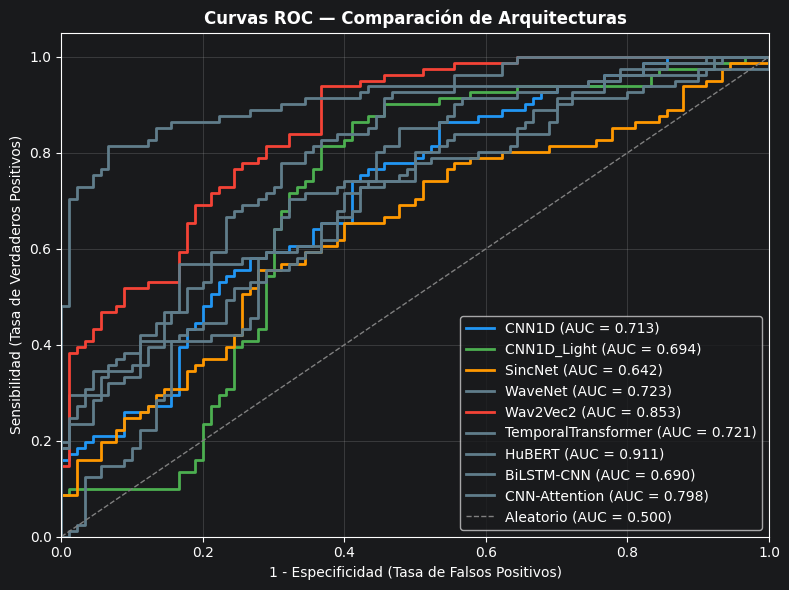

In [31]:
from src.visualization import plot_roc_curves

plot_roc_curves(eval_results)

## Matrices de confusión

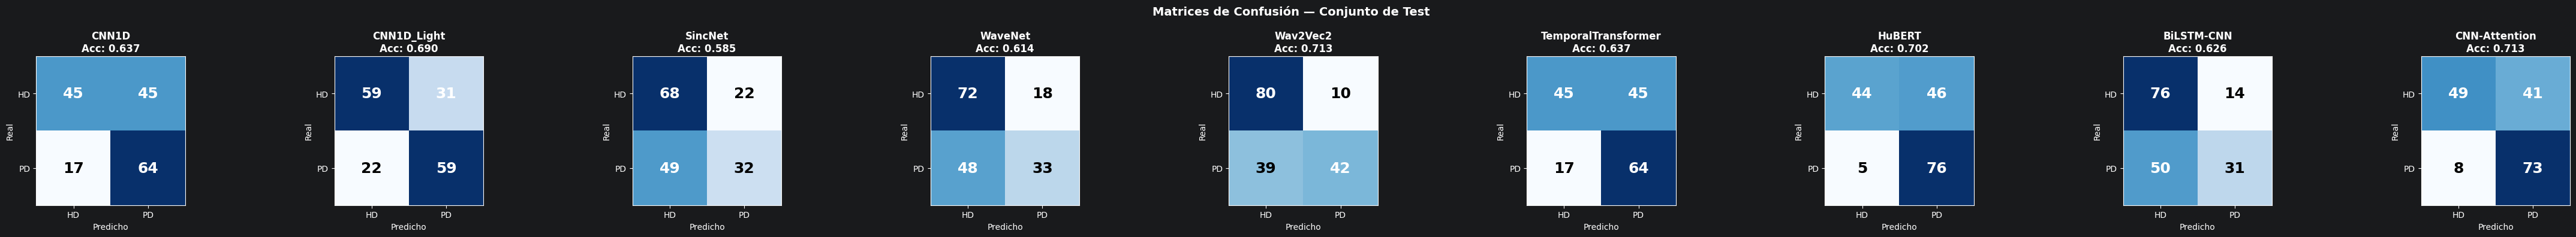

In [32]:
from src.visualization import plot_confusion_matrices

plot_confusion_matrices(eval_results)

## Ejecución por hiperparámetros

In [33]:
from src.training import run_kfold_search

final_results = run_kfold_search(
    df=df_metadata,
    waveforms_processed=waveforms_processed,
    model_config=MODEL_CONFIG,
    hyperparam_grid=HYPERPARAM_GRID,
    n_folds=N_FOLDS,
    random_state=RANDOM_STATE,
    window_len=WINDOW_LEN,
    hop_len=HOP_LEN
)

2026-06-30 23:27:05,163 [INFO] src.config: 
2026-06-30 23:27:05,163 [INFO] src.config:   WavLM
2026-06-30 23:27:05,163 [INFO] src.config: ======================================================================
2026-06-30 23:27:05,531 [INFO] httpx: HTTP Request: HEAD https://huggingface.co/microsoft/wavlm-base/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
2026-06-30 23:27:05,599 [INFO] httpx: HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/microsoft/wavlm-base/efa81aae7ff777e464159e0f877d54eac5b84f81/config.json "HTTP/1.1 200 OK"
2026-06-30 23:27:05,714 [INFO] httpx: HTTP Request: HEAD https://huggingface.co/microsoft/wavlm-base/resolve/main/model.safetensors "HTTP/1.1 404 Not Found"
2026-06-30 23:27:05,810 [INFO] httpx: HTTP Request: HEAD https://huggingface.co/microsoft/wavlm-base/resolve/main/model.safetensors.index.json "HTTP/1.1 404 Not Found"
2026-06-30 23:27:05,954 [INFO] httpx: HTTP Request: HEAD https://huggingface.co/microsoft/wavlm-base/resolve/

KeyboardInterrupt: 

### Evaluación de métricas por hiperparámetros

In [ ]:
# ============================================================
# TABLA FINAL: K-FOLD CON MEJORES HIPERPARÁMETROS
# ============================================================
print(f"\n{'='*90}")
print(f"  RESULTADOS FINALES — {N_FOLDS}-Fold CV + Umbral de Youden + Evaluación por Sujeto")
print(f"{'='*90}")
print(f"\n{'Modelo':<20} {'lr':>8} {'bs':>4} {'AUC':>12} {'Acc':>12} "
      f"{'Sens':>12} {'Spec':>12} {'F1':>12} {'MCC':>12}")
print("-" * 104)

# Ordenar por AUC descendente
sorted_results = sorted(final_results.items(), key=lambda x: x[1]["auc_mean"], reverse=True)

for name, r in sorted_results:
    print(f"{name:<20} {r['best_lr']:>8.0e} {r['best_bs']:>4} "
          f"{r['auc_mean']:>5.3f}±{r['auc_std']:.3f} "
          f"{r['acc_mean']:>5.3f}±{r['acc_std']:.3f} "
          f"{r['sens_mean']:>5.3f}±{r['sens_std']:.3f} "
          f"{r['spec_mean']:>5.3f}±{r['spec_std']:.3f} "
          f"{r['f1_mean']:>5.3f}±{r['f1_std']:.3f} "
          f"{r['mcc_mean']:>5.3f}±{r['mcc_std']:.3f}")

### Matrices de confusión por hiperparámetros

In [ ]:
from src.visualization import plot_top_confusion_matrices

plot_top_confusion_matrices(sorted_results, top_n=6)

### Curvas ROC por hiperparámetros

In [ ]:
from src.visualization import plot_kfold_roc_curves

plot_kfold_roc_curves(sorted_results, n_folds=N_FOLDS)

# Experimentos

## Estrategia: Embeddings Congelados + PCA + SVM

### Concepto Matemático

Esta estrategia se basa en un principio fundamental del *transfer learning*: usar un modelo
preentrenado como **extractor de características** sin modificar sus pesos. El pipeline tiene
tres etapas:

**1. Extracción de embeddings (Feature Extraction)**

Dado un modelo preentrenado $f_\theta$ con parámetros congelados $\theta$, para cada señal
de audio $x_i$ se obtiene una secuencia de representaciones contextuales:

$$H_i = f_\theta(x_i) \in \mathbb{R}^{T_i \times D}$$

donde $T_i$ es el número de frames temporales y $D$ la dimensión del embedding (768 para BASE,
1024 para LARGE). Para obtener un vector fijo por muestra, se aplica **mean pooling temporal**:

$$\bar{h}_i = \frac{1}{T_i} \sum_{t=1}^{T_i} H_i[t, :] \in \mathbb{R}^{D}$$

**2. Reducción de dimensionalidad con PCA**

El espacio de $D$ dimensiones es excesivo para un clasificador clásico con $N \approx 100$
muestras (maldición de la dimensionalidad). PCA encuentra las $k \ll D$ direcciones de máxima
varianza:

$$Z_i = W_{PCA}^T (\bar{h}_i - \mu) \in \mathbb{R}^{k}$$

donde $W_{PCA} \in \mathbb{R}^{D \times k}$ son los $k$ eigenvectores principales de la
matriz de covarianza de los embeddings de entrenamiento.

**3. Clasificación con SVM (Support Vector Machine)**

SVM busca el hiperplano de máximo margen en el espacio reducido $\mathbb{R}^k$:

$$\max_{w,b} \frac{2}{\|w\|} \quad \text{s.t.} \quad y_i(w^T z_i + b) \geq 1 \; \forall i$$

Con kernel RBF, la clasificación se realiza en un espacio de dimensión infinita implícita,
capturando fronteras de decisión no lineales.

### ¿Por qué funciona mejor que fine-tuning con pocos datos?

Con $N \approx 100$ muestras, fine-tuning ajusta millones de parámetros y sobreajusta
fácilmente. En cambio, este pipeline:

- **Extracción**: 0 parámetros entrenables (todo congelado)
- **PCA**: Ajuste no supervisado, no depende de etiquetas
- **SVM**: Pocos hiperparámetros (C, gamma), regularización implícita por el margen

El resultado es un sistema con capacidad efectiva mucho menor, apropiado para datasets pequeños.

In [ ]:
from src.embeddings import run_embedding_svm_search

EMBEDDING_MODELS = {
    "Wav2Vec2_BASE":  "facebook/wav2vec2-base",
    "Wav2Vec2_LARGE": "facebook/wav2vec2-large",
    "HuBERT_BASE":    "facebook/hubert-base-ls960",
    "WavLM_BASE":     "microsoft/wavlm-base",
}

PCA_COMPONENTS = [3, 5, 10, 20]
SVM_C = [0.1, 1.0, 10.0]
SVM_KERNEL = ["rbf", "linear"]

N_FOLDS = 5
RANDOM_STATE = 42

windowed_emb_results = run_embedding_svm_search(
    df=df_metadata,
    waveforms_processed=waveforms_processed,
    embedding_models=EMBEDDING_MODELS,
    pca_components=PCA_COMPONENTS,
    svm_c=SVM_C,
    svm_kernels=SVM_KERNEL,
    n_folds=N_FOLDS,
    random_state=RANDOM_STATE,
    window_len=WINDOW_LEN,
    hop_len=HOP_LEN
)


for name, r in windowed_emb_results.items():
    print(f"\n  {name}: PCA={r['best_pca']} C={r['best_C']} kernel={r['best_kernel']}")
    print(f"     AUC:  {r['auc_mean']:.3f} ± {r['auc_std']:.3f}")
    print(f"     Acc:  {r['acc_mean']:.3f} ± {r['acc_std']:.3f}")
    print(f"     Sens: {r['sens_mean']:.3f} ± {r['sens_std']:.3f}")
    print(f"     Spec: {r['spec_mean']:.3f} ± {r['spec_std']:.3f}")

In [ ]:
# ============================================================
# COMPARATIVA: SEÑAL COMPLETA vs WINDOWED EMBEDDINGS
# ============================================================
print(f"\n{'='*85}")
print(f"  COMPARACIÓN: Embeddings Señal Completa vs Windowed + Evaluación por Sujeto")
print(f"{'='*85}")

print(f"\n  WINDOWED (ventana={WINDOW_SEC}s, hop={HOP_SEC}s):")
print(f"  {'Modelo':<22} {'PCA':>5} {'Config':<15} {'AUC':>12} {'Acc':>12}")
print(f"  {'-'*68}")
for name, res in windowed_emb_results.items():
    cfg = f"C={res['best_C']} {res['best_kernel']}"
    print(f"  {name:<22} {res['best_pca']:>5} {cfg:<15} "
          f"{res['auc_mean']:.3f}±{res['auc_std']:.3f} "
          f"{res['acc_mean']:.3f}±{res['acc_std']:.3f}")

# Experimento con embeddings, concatenacion

In [ ]:
from src.embeddings import extract_fusion_embeddings

FUSION_MODELS = [
    "facebook/wav2vec2-base",
    "facebook/wav2vec2-large",
    "facebook/hubert-base-ls960",
]

emb_fusion, fusion_labels = extract_fusion_embeddings(
    df=df_metadata,
    waveforms_processed=waveforms_processed,
    model_names=FUSION_MODELS,
)

In [ ]:
from src.embeddings import run_fusion_svm_search, extract_embeddings

# Extraer WavLM (los demás ya los tienes de extract_fusion_embeddings)
all_indices = np.arange(len(waveforms_processed))
emb_wavlm, _ = extract_embeddings(df_metadata, waveforms_processed, all_indices, "microsoft/wavlm-base")
emb_base, _   = extract_embeddings(df_metadata, waveforms_processed, all_indices, "facebook/wav2vec2-base")
emb_large, _  = extract_embeddings(df_metadata, waveforms_processed, all_indices, "facebook/wav2vec2-large")
emb_hubert, _ = extract_embeddings(df_metadata, waveforms_processed, all_indices, "facebook/hubert-base-ls960")
emb_wavlm, _  = extract_embeddings(df_metadata, waveforms_processed, all_indices, "microsoft/wavlm-base")

FUSION_CONFIGS = {
    "BASE+LARGE":          np.concatenate([emb_base, emb_large], axis=1),
    "BASE+HuBERT":         np.concatenate([emb_base, emb_hubert], axis=1),
    "BASE+WavLM":          np.concatenate([emb_base, emb_wavlm], axis=1),
    "LARGE+HuBERT+WavLM": np.concatenate([emb_large, emb_hubert, emb_wavlm], axis=1),
    "ALL_4":               np.concatenate([emb_base, emb_large, emb_hubert, emb_wavlm], axis=1),
}

fusion_results = run_fusion_svm_search(
    fusion_configs=FUSION_CONFIGS,
    labels=fusion_labels,
    pca_components=[3, 5, 10, 20, 50],
    svm_c=[0.1, 1.0, 10.0],
    svm_kernels=["rbf", "linear"],
)

for name, r in fusion_results.items():
    print(f"\n  ✅ {name}: PCA={r['best_pca']} C={r['best_C']} kernel={r['best_kernel']}")
    print(f"     AUC:  {r['auc_mean']:.3f} ± {r['auc_std']:.3f}")
    print(f"     Acc:  {r['acc_mean']:.3f} ± {r['acc_std']:.3f}")